# Домашнее задание 2. Линейные модели и регуляризация

В этом домашнем задании вы будете работать с набором данных по добыче газа: необходимо оценить, сколько денег будет приносить каждая из скважин, а также понять, какие факторы (параметры скважин) потенциально сильнее всего повлияют на объём добычи газа.
Ваша задача — пройти полный базовый цикл построения модели: от анализа и предобработки данных до обучения и улучшения линейной регрессии.

Итоговая цель — построить интерпретируемую и устойчивую модель, предсказывающую суточную добычу газа на основе геологических характеристик скважины.

**Описание признаков**

| Признак                | Описание                        |
| ---------------------- | ------------------------------- |
| `well_id`              | идентификатор скважины          |
| `porosity`             | пористость скважины             |
| `permeability`         | проницаемость скважины          |
| `acoustic_impedance`   | акустический импеданс           |
| `brittleness`          | коэффициент хрупкости скважины  |
| `organic_carbon`       | общий органический углерод      |
| `vitrinite_reflectance`| коэффициент отражения витринита |

**Целевая переменная**

`extr_per_day` — добыча газа в сутки (млн кубических футов).


In [174]:
# Импорт нужных библиотек и моделей,
# Добавляйте в ячейку все, что потребуется

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, \
                            mean_squared_error, r2_score

In [175]:
import warnings
warnings.filterwarnings("ignore")

In [176]:
pd.options.display.float_format = '{:.2f}'.format

### Задание 1
Первым делом **познакомимся с данными**, а заодно закрепим методы работы с Pandas.

0. Прочитайте файл, посмотрите на семпл и количество строк.
1. Проверьте наличие пропусков в данных и при необходимости обработайте их.  
2. Проверьте наличие выбросов  и ошибочных значений (тут полезно обратиться к смыслу признаков) и при необходимости почистите их.
3. Проверьте наличие дубликатов и при необходимости почистите их.
4. Подумайте, есть ли в данных неинформативные признаки, при необходимости удалите их.
5. Запишите наблюдения в виде небольшого вывода.

	Первые 5 строк данных


,well_id,porosity,permeability,acoustic_impedance,brittleness,organic_carbon,vitrinite_reflectance,extr_per_day
0,1,12.08,2.92,2.80,81.40,1.16,2.31,4165.20
1,2,12.38,3.53,3.22,46.17,0.89,1.88,3561.15
2,3,14.02,2.59,4.01,72.80,0.89,2.72,4284.35
3,4,17.67,6.75,2.63,39.81,1.08,1.88,5098.68
4,5,17.52,4.57,3.18,10.94,1.51,1.90,3406.13


Размер датасета: (200, 8)
Количество строк: 200
Количество признаков: 8

	Информация о данных
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   well_id                200 non-null    int64  
 1   porosity               200 non-null    float64
 2   permeability           200 non-null    float64
 3   acoustic_impedance     200 non-null    float64
 4   brittleness            200 non-null    float64
 5   organic_carbon         200 non-null    float64
 6   vitrinite_reflectance  200 non-null    float64
 7   extr_per_day           200 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 12.7 KB
None

	Пропуски в данных
well_id                  0
porosity                 0
permeability             0
acoustic_impedance       0
brittleness              0
organic_carbon           0
vitrinite_reflectance    0
extr_per_day             0
d

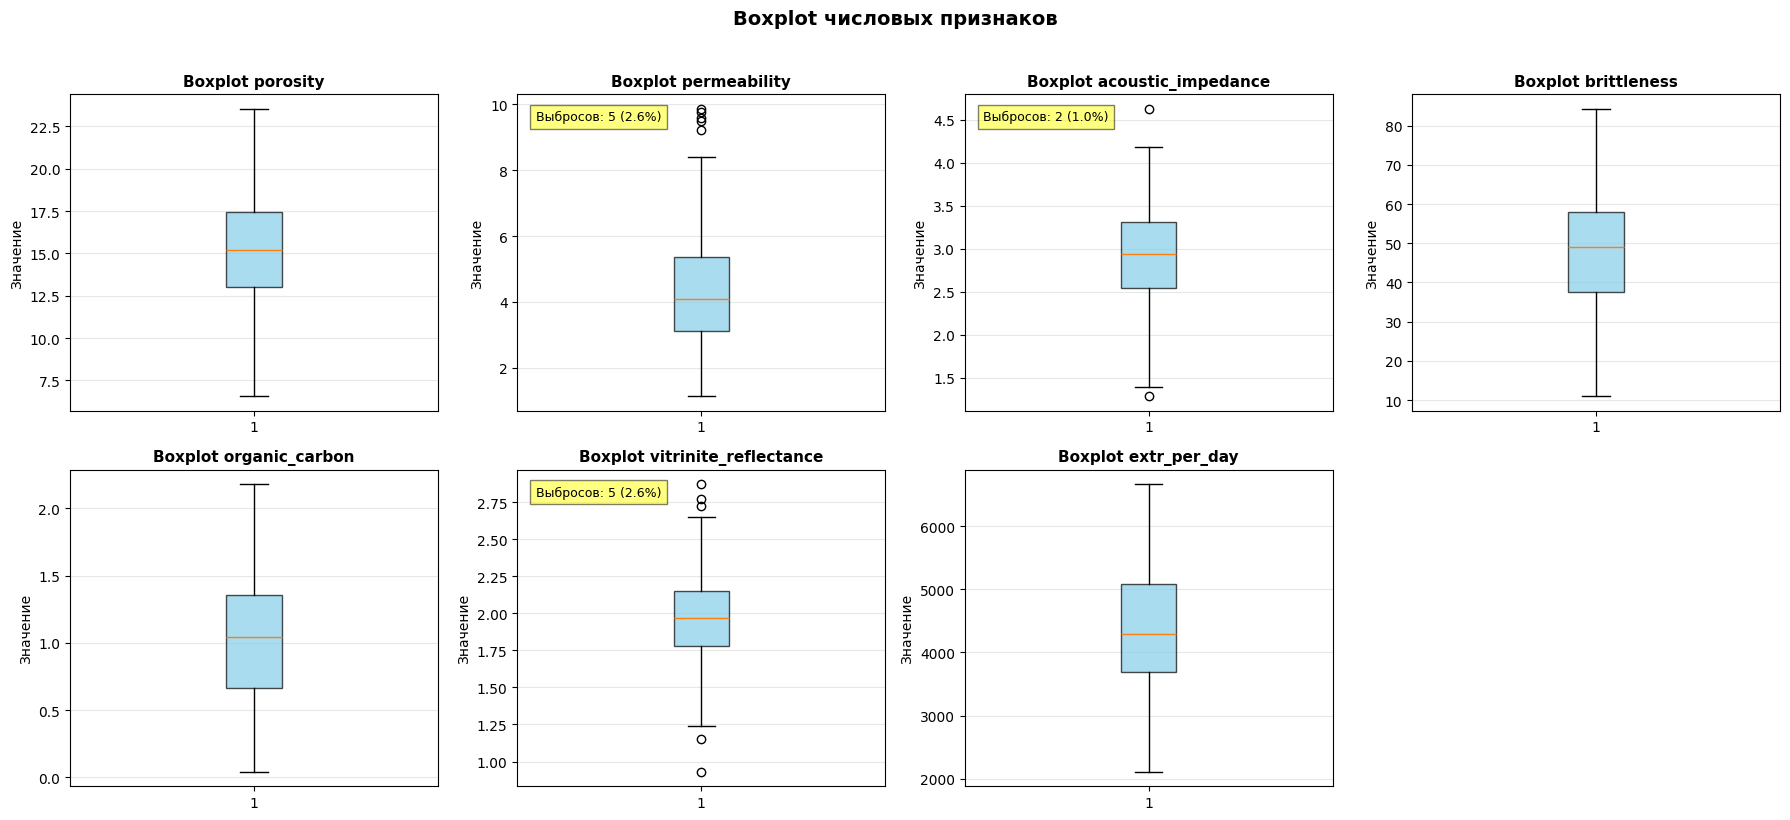

	Проверка наличия дубликатов
Количество полных дубликатов строк: 0
Дубликаты отсутствуют

Итоговый размер данных: (196, 7)
Количество признаков после очистки: 6


In [177]:
"""
ВАШЕ РЕШЕНИЕ
"""
# 0. Чтение файла, посмотр семпла и количество строк
df = pd.read_csv("well_data.csv")

print("\tПервые 5 строк данных")
display(df.head())

print(f"Размер датасета: {df.shape}")
print(f"Количество строк: {df.shape[0]}")
print(f"Количество признаков: {df.shape[1]}")

# 1. Проверка наличия пропусков в данных
print("\n\tИнформация о данных")
print(df.info())

print("\n\tПропуски в данных")
print(df.isnull().sum())

# 2. Проверка наличие выбросов и ошибочных значений
print("\n\tСтатистическое описание данных")
print(df.describe())

# Проверяем физический смысл признаков
print("\n\tПроверка физического смысла признаков")
init_len = len(df)
total_removed = 0

# Пористость porosity обычно от 0 до 40 %
porosity_removed = df[(df['porosity'] < 0) | (df['porosity'] > 40)]
if len(porosity_removed) > 0:
    print(f"porosity: {len(porosity_removed)} некорректных значений")
    df = df[(df['porosity'] >= 0) & (df['porosity'] <= 40)]
    total_removed += len(porosity_removed)

# Проницаемость permeability не может быть отрицательной
permeability_removed = df[df['permeability'] < 0]
if len(permeability_removed) > 0:
    print(f"permeability: {len(permeability_removed)} некорректных значений")
    df = df[df['permeability'] >= 0]
    total_removed += len(permeability_removed)

# Акустический импеданс acoustic_impedance всегда положительный
impedance_removed = df[df['acoustic_impedance'] <= 0]
if len(impedance_removed) > 0:
    print(f"acoustic_impedance: {len(impedance_removed)} " \
          f"некорректных значений")
    df = df[df['acoustic_impedance'] > 0]
    total_removed += len(impedance_removed)

# Коэффициент хрупкости brittleness обычно от 0 до 100
brittleness_removed = df[(df['brittleness'] < 0) | (df['brittleness'] > 100)]
if len(brittleness_removed) > 0:
    print(f"brittleness: {len(brittleness_removed)} некорректных значений")
    df = df[(df['brittleness'] >= 0) & (df['brittleness'] <= 100)]
    total_removed += len(brittleness_removed)

# Органический углерод organic_carbon не может быть отрицательным
organic_removed = df[df['organic_carbon'] < 0]
if len(organic_removed) > 0:
    print(f"organic_carbon: {len(organic_removed)} некорректных значений")
    df = df[df['organic_carbon'] >= 0]
    total_removed += len(organic_removed)

# Коэффициент отражения витринита vitrinite_reflectance всегда положительный
reflectance_removed = df[df['vitrinite_reflectance'] < 0]
if len(reflectance_removed) > 0:
    print(f"vitrinite_reflectance: {len(reflectance_removed)} " \
          f"некорректных значений")
    df = df[df['vitrinite_reflectance'] >= 0]
    total_removed += len(reflectance_removed)

# Добыча extr_per_day не может быть отрицательной
extraction_removed = df[df['extr_per_day'] < 0]
if len(extraction_removed) > 0:
    print(f"extr_per_day: {len(extraction_removed)} некорректных значений")
    df = df[df['extr_per_day'] >= 0]
    total_removed += len(extraction_removed)

# Выводим итоговую информацию
print(f"\n\tИтог по удалению некорректных значений")
print(f"Начальный размер данных: {init_len} строк")
print(f"Конечный размер данных: {len(df)} строк")
print(f"Удалено строк: {total_removed}")

print(f"\n\tСтатистическое описание данных после удаления некорректных "\
      f"значений")
print(df.describe())

print("\n\tПроверка наличия выбросов методом межквартильного размаха")

def find_iqr_outliers(df, columns, k=1.5):
    """
    Возвращает словарь с выбросами по IQR для указанных столбцов.

    df : pandas.DataFrame
    columns : list[str] — числовые признаки
    k : коэффициент IQR (обычно 1.5)
    """
    outliers = {}

    for col in columns:
        # Вычисляем квартили и IQR
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        # Вычисляем границы
        lower_bound = q1 - k * iqr
        upper_bound = q3 + k * iqr

        # Находим выбросы
        mask = (df[col] < lower_bound) | (df[col] > upper_bound)
        outliers[col] = df.loc[mask, col]

    return outliers

columns = [col for col in df.columns.tolist() if col != 'well_id']
outliers = find_iqr_outliers(df, columns)

outliers_summary = {}
for col, outlier_values in outliers.items():
    outliers_count = len(outlier_values)
    if outliers_count > 0:
        outliers_percentage = outliers_count / len(df) * 100
        print(f"{col}: {outliers_count} выбросов "\
              f"({outliers_percentage:.1f}%)")
        outliers_summary[col] = {
            "count": outliers_count,
            "percentage": outliers_percentage,
            "min_outlier": (
                outlier_values.min() if not outlier_values.empty else None
            ),
            "max_outlier": (
                outlier_values.max() if not outlier_values.empty else None
            ),
        }
    else:
        print(f"{col}: выбросов не обнаружено")

# Boxplot для числовых признаков (без well_id)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for i, col in enumerate(columns):
    if i < len(axes):
        # Boxplot
        bp = axes[i].boxplot(df[col], patch_artist=True)
        bp['boxes'][0].set_facecolor('skyblue')
        bp['boxes'][0].set_alpha(0.7)

        axes[i].set_title(f'Boxplot {col}', fontweight='bold', fontsize=11)
        axes[i].set_ylabel('Значение')
        axes[i].grid(True, alpha=0.3, axis='y')

        # Добавляем аннотацию с информацией о выбросах
        if col in outliers_summary:
            axes[i].text(
                0.05,
                0.95,
                (
                    f"Выбросов: {outliers_summary[col]['count']} "
                    f"({outliers_summary[col]['percentage']:.1f}%)"
                ),
                transform=axes[i].transAxes,
                fontsize=9,
                verticalalignment='top',
                bbox=dict(facecolor='yellow', alpha=0.5),
            )

# Скрываем лишний график
if len(columns) < len(axes):
    axes[len(columns)].axis('off')

plt.suptitle(
    'Boxplot числовых признаков',
    fontsize=14,
    fontweight='bold',
    y=1.02,
)
plt.tight_layout()
plt.show()

# 3. Проверка дубликатов
print("\tПроверка наличия дубликатов")
duplicates_count = df.duplicated().sum()
print(f"Количество полных дубликатов строк: {duplicates_count}")
df = df.drop_duplicates()
if duplicates_count > 0:
    print(f"Удалено дубликатов: {duplicates_count}")
else:
    print("Дубликаты отсутствуют")

# 4. Неинформативные признаки
# well_id - идентификатор, не несет информации для модели
df = df.drop("well_id", axis=1)

print(f"\nИтоговый размер данных: {df.shape}")
print(f"Количество признаков после очистки: {df.shape[1] - 1}")  # -1 target

**Вывод:** 

В ходе предобработки данных было проведено комплексное исследование всех числовых признаков:

1. **Пропуски:**
   - Пропуски отсутствуют во всех 8 признаках
   - Все 200 записей содержат полные данные, что упрощает предобработку и не требует применения методов заполнения пропусков

2. **Ошибочные значения (проверка физического смысла):**
   - В ходе проверки физического смысла признаков обнаружены и удалены отрицательные значения органического углерода (`organic_carbon`), которые физически невозможны, так как содержание органического вещества не может быть отрицательным
   - Всего удалено 4 строки с некорректными значениями
   - После очистки в данных осталось 196 строк

3. **Выбросы (метод межквартильного размаха с k=1.5):**
   - `permeability`: 5 выбросов (2.6%) 
   - `acoustic_impedance`: 2 выброса (1.0%) 
   - `vitrinite_reflectance`: 5 выбросов (2.6%)
   - `porosity`, `brittleness`, `organic_carbon`, `extr_per_day`: выбросов не обнаружено после удаления некорректных значений
   
   Выбросы сохранены в данных, так как они могут отражать реальные геологические особенности скважин

4. **Дубликаты:**
   
   Полные дубликаты строк отсутствуют. Все записи уникальны

5. **Неинформативные признаки:**
   
   Признак `well_id` удален как неинформативный, так как является просто порядковым номером скважины и не несет полезной информации для прогнозирования добычи газа

6. **Итоговый размер данных:**
   - После очистки: 196 строк, 7 признаков (6 факторов + целевая переменная `extr_per_day`)
   - Все признаки числовые, что упрощает построение линейных моделей

## Задание 2

Проведем небольшой **EDA.**

1. Посмотрите на распределение целевого признака `extr_per_day`.
2. Изучите распределения остальных признаков, а также парные зависимости (можете воспользоваться `pairplot` либо построить графики по отдельности).
3. Постройте матрицу корреляций, визуализируйте ее и проанализируйте наличие мультиколлинеарных признаков (в качестве порога можно взять ±0.7).
4. Зафиксируйте наблюдения в небольшом выводе.

	Анализ целевой переменной extr_per_day


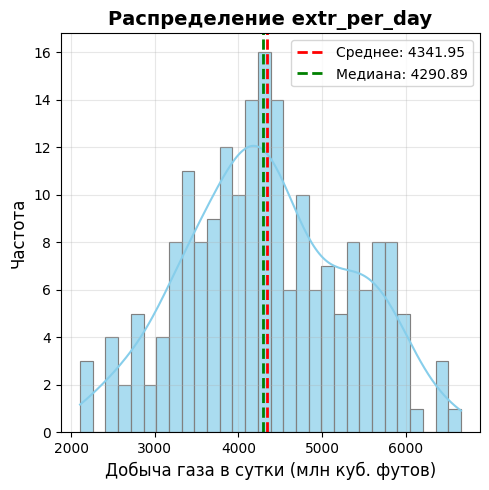

	Статистика целевой переменной extr_per_day
Среднее: 4341.95
Медиана: 4290.89
Стандартное отклонение: 975.96
Минимум: 2107.14
Максимум: 6662.62
Асимметрия (skewness): 0.07
Эксцесс (kurtosis): -0.50


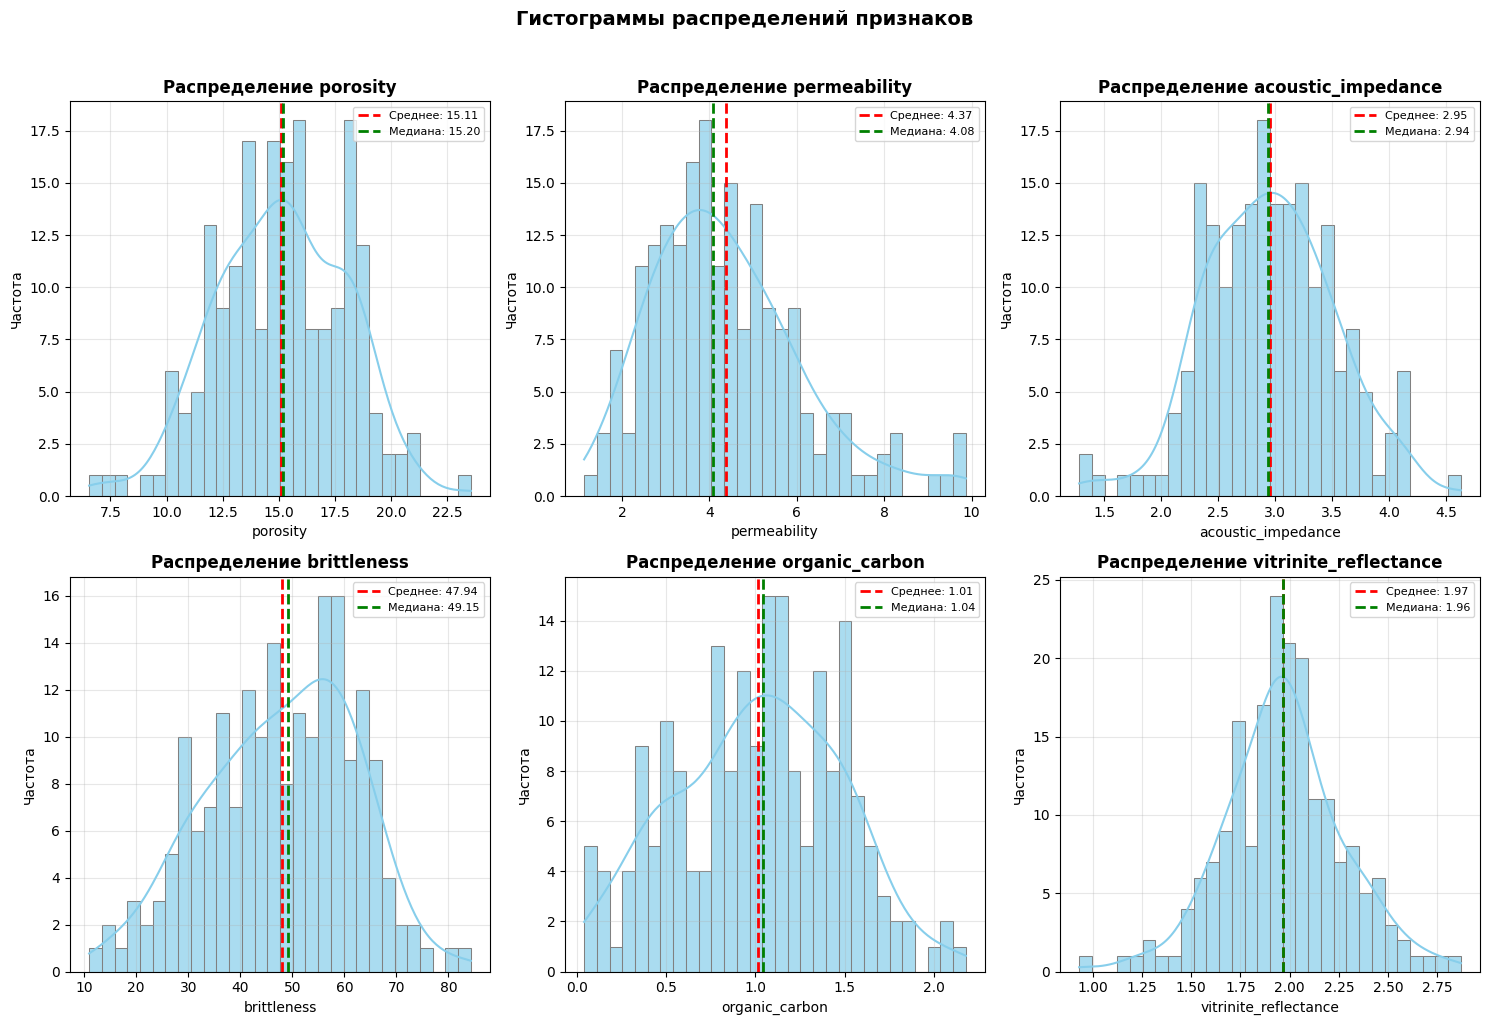

			Статистика признаков

              Признак  Среднее  Медиана  Стандартное отклонение  Минимум  Максимум  Асимметрия (skewness)  Эксцесс (kurtosis)
             porosity    15.11    15.20                    2.87     6.55     23.55                  -0.12               -0.09
         permeability     4.37     4.08                    1.72     1.13      9.87                   0.87                0.87
   acoustic_impedance     2.95     2.94                    0.56     1.28      4.63                   0.01                0.24
          brittleness    47.94    49.15                   14.18    10.94     84.33                  -0.24               -0.41
       organic_carbon     1.01     1.04                    0.46     0.04      2.18                  -0.05               -0.55
vitrinite_reflectance     1.97     1.96                    0.30     0.93      2.87                   0.01                0.81


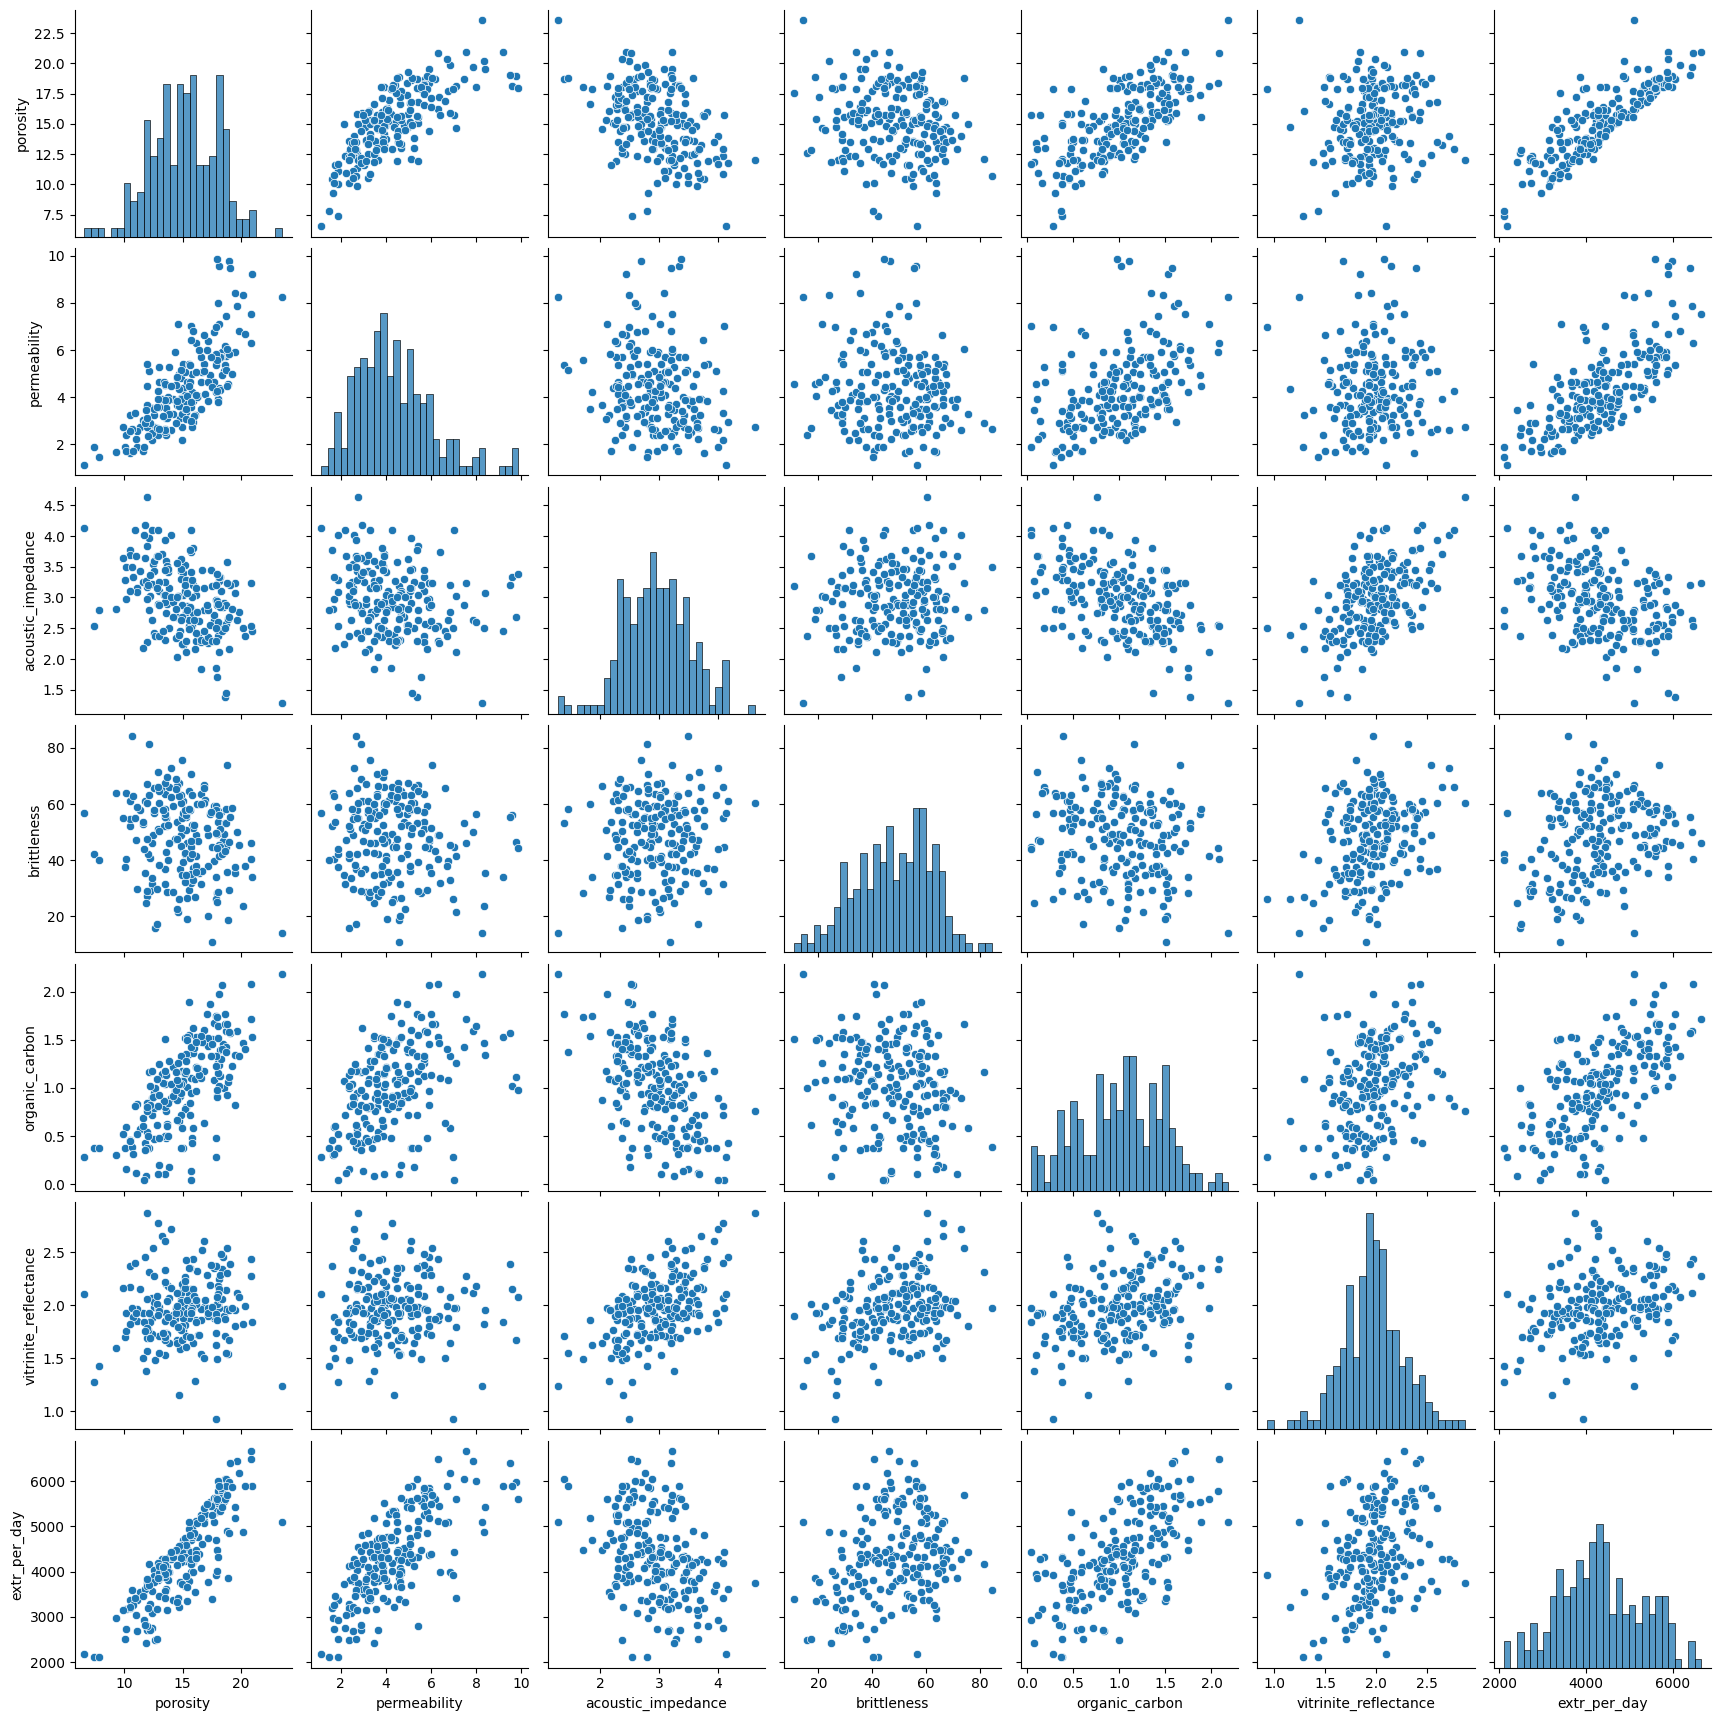

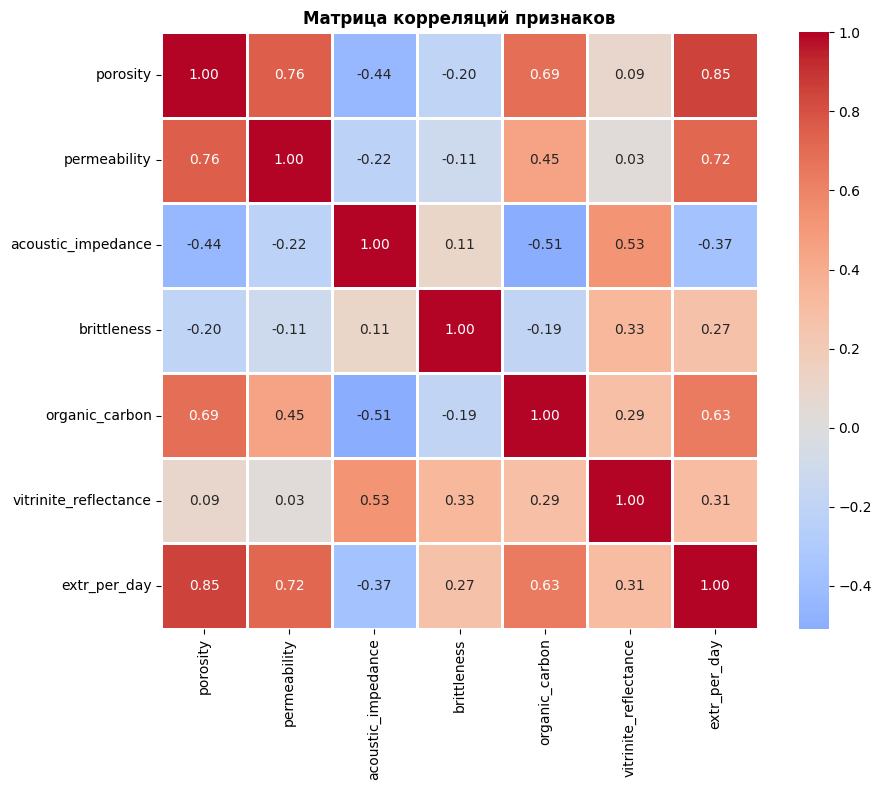

	Анализ мультиколлинеарности
porosity и permeability: 0.76
porosity и extr_per_day: 0.85
permeability и extr_per_day: 0.72

	Корреляция признаков с целевой переменной extr_per_day
porosity: 0.85 (сильная положительная связь)
permeability: 0.72 (сильная положительная связь)
acoustic_impedance: -0.37 (слабая отрицательная связь)
brittleness: 0.27 (слабая положительная связь)
organic_carbon: 0.63 (умеренная положительная связь)
vitrinite_reflectance: 0.31 (слабая положительная связь)


In [178]:
"""
ВАШЕ РЕШЕНИЕ
"""
# 1. Распределение целевого признака
print("\tАнализ целевой переменной extr_per_day")

# Гистограмма распределения
fig, ax = plt.subplots(figsize=(5, 5))

sns.histplot(
    data=df,
    x='extr_per_day',
    kde=True,
    ax=ax,
    edgecolor='gray',
    bins=30,
    color='skyblue',
    alpha=0.7
)
ax.set_title('Распределение extr_per_day', fontweight='bold', fontsize=14)
ax.set_xlabel('Добыча газа в сутки (млн куб. футов)', fontsize=12)
ax.set_ylabel('Частота', fontsize=12)
ax.grid(True, alpha=0.3)

# Добавляем вертикальные линии для среднего и медианы
mean_val = df['extr_per_day'].mean()
median_val = df['extr_per_day'].median()
ax.axvline(
    mean_val,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Среднее: {mean_val:.2f}'
)
ax.axvline(
    median_val,
    color='green',
    linestyle='--',
    linewidth=2,
    label=f'Медиана: {median_val:.2f}'
)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Выводим статистику целевой переменной
print("\tСтатистика целевой переменной extr_per_day")
print(f"Среднее: {df['extr_per_day'].mean():.2f}")
print(f"Медиана: {df['extr_per_day'].median():.2f}")
print(f"Стандартное отклонение: {df['extr_per_day'].std():.2f}")
print(f"Минимум: {df['extr_per_day'].min():.2f}")
print(f"Максимум: {df['extr_per_day'].max():.2f}")
print(f"Асимметрия (skewness): {df['extr_per_day'].skew():.2f}")
print(f"Эксцесс (kurtosis): {df['extr_per_day'].kurtosis():.2f}")

# 2. Изучение распределений остальных признаков
features = [col for col in df.columns if col != 'extr_per_day']

# Создаем гистограммы для всех признаков
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, feature in enumerate(features):
    if i < len(axes):
        sns.histplot(
            data=df,
            x=feature,
            kde=True,
            ax=axes[i],
            edgecolor='gray',
            bins=30,
            color='skyblue',
            alpha=0.7
        )
        axes[i].set_title(f'Распределение {feature}', fontweight='bold', 
                          fontsize=12)
        axes[i].set_xlabel(feature, fontsize=10)
        axes[i].set_ylabel('Частота', fontsize=10)
        axes[i].grid(True, alpha=0.3)
        
        # Добавляем линии среднего и медианы
        mean_val = df[feature].mean()
        median_val = df[feature].median()
        axes[i].axvline(
            mean_val,
            color='red',
            linestyle='--',
            linewidth=2,
            label=f'Среднее: {mean_val:.2f}'
        )
        axes[i].axvline(
            median_val,
            color='green',
            linestyle='--',
            linewidth=2,
            label=f'Медиана: {median_val:.2f}'
        )
        axes[i].legend(fontsize=8, loc='upper right')

plt.suptitle('Гистограммы распределений признаков', fontsize=14, 
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

features = [col for col in df.columns if col != 'extr_per_day']

# Выводим статистику по всем признакам
print("\t\t\tСтатистика признаков\n")
stats_df = pd.DataFrame({
    'Признак': features,
    'Среднее': [df[col].mean() for col in features],
    'Медиана': [df[col].median() for col in features],
    'Стандартное отклонение': [df[col].std() for col in features],
    'Минимум': [df[col].min() for col in features],
    'Максимум': [df[col].max() for col in features],
    'Асимметрия (skewness)': [df[col].skew() for col in features],
    'Эксцесс (kurtosis)': [df[col].kurtosis() for col in features]
    
})
print(stats_df.round(2).to_string(index=False))

# Pairplot всех признаков
sns.pairplot(df, diag_kws={'bins': 30})
plt.show()

# 3. Матрица корреляций и анализ наличия мультиколлинеарных признаков
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()

# Визуализация тепловой карты
sns.heatmap(
    correlation_matrix,    
    annot=True,            
    cmap='coolwarm',       
    center=0,              
    square=True,           
    linewidths=1,          
    fmt='.2f'             
)
plt.title('Матрица корреляций признаков', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\tАнализ мультиколлинеарности")
pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

if pairs:
    for pair in pairs:
        print(f"{pair[0]} и {pair[1]}: {pair[2]:.2f}")
else:
    print("Сильно коррелирующих признаков не обнаружено")

print("\n\tКорреляция признаков с целевой переменной extr_per_day")
correlation = correlation_matrix['extr_per_day'].drop('extr_per_day')
for feature, corr in correlation.items():
    if abs(corr) > 0.7:
        power = "сильная"
    elif abs(corr) > 0.5:
        power = "умеренная"
    else:
        power = "слабая"
    direction = "положительная" if corr > 0 else "отрицательная"
    print(f"{feature}: {corr:.2f} ({power} {direction} связь)")

**Вывод:** 

В ходе разведочного анализа данных (EDA) были получены следующие ключевые наблюдения:
   
1. **Распределение целевой переменной:**

Распределение `extr_per_day` близко к нормальному (среднее и медиана почти совпадают). Коэффициент асимметрии (skewness) близок к нулю (0.07), что подтверждает симметричность распределения. Отрицательный эксцесс (kurtosis = -0.50) указывает на то, что распределение является более плосковершинным по сравнению с нормальным распределением.

2. **Распределения признаков:** 

Большинство признаков (`porosity`, `permeability`, `acoustic_impedance`) имеют распределения, близкие к нормальным 

3. **Матрица корреляций и мультиколлинеарность:** Выявлена сильная положительная корреляция между `porosity` и `permeability` (0.76), между `porosity` и `extr_per_day` (0.85), и между `permeability` и `extr_per_day` (0.72). Это указывает на мультиколлинеарность между `porosity` и `permeability` 

4. **Корреляция с целевой переменной:**
   - `porosity`: 0.85 (сильная положительная). Чем выше пористость, тем выше добыча. Самый важный признак
   - `permeability`: 0.72 (сильная положительная). Чем выше проницаемость, тем выше добыча. Второй по важности признак
   - `organic_carbon`: 0.63 (умеренная положительная). Содержание органического углерода положительно влияет на добычу
   - `vitrinite_reflectance`: 0.31 (слабая положительная)
   - `acoustic_impedance`: -0.37 (слабая отрицательная)
   - `brittleness`: 0.27 (слабая положительная)

## Задание 3

**Финально подготовим данные для модели.**

* По итогам EDA удалите сильно скоррелированные признаки, если они нашлись.
* Создайте матрицу признаков `X` и вектор таргета `y`.
* Разбейте данные на тренировочную и тестовую выборку, установите соотношение 80/20 и random_state=42.
* Выберите подходящий способ масштабирования или нормализации данных, примените его для обеих выборок. Также на этом этапе добавьте единичный столбец для вручную применяемых алгоритмов.
* Зафиксируйте все преобразования и обоснования в небольшом выводе.

In [179]:
"""
ВАШЕ РЕШЕНИЕ
"""
# Удалим permeability, поскольку у него ниже корреляция с целевой переменной,
# чем у porosity (0.72 против 0.85), кроме того, porosity не содержит выбросов
df_model = df.drop(columns=['permeability'])
display(df_model.head())

# Создадим матрицу признаков X и вектора таргета y
X = df_model.drop(columns=['extr_per_day']).values  # Признаки
y = df_model['extr_per_day'].values                 # Целевая переменная

# Разделим на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42)

print("\tРазмеры выборок после разделения")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

# Масштабируем данные
# Используем StandardScaler (распределения близки к нормальному)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Добавим единичный столбец (смещения/bias)
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

print("\n\tРазмеры выборок после масштабирования и добавления bias-столбца")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

feature_names = ['bias'] + \
                [col for col in df_model.columns if col != 'extr_per_day']
X_train_df = pd.DataFrame(
    X_train[:5],
    columns=feature_names
)
display(X_train_df)

,porosity,acoustic_impedance,brittleness,organic_carbon,vitrinite_reflectance,extr_per_day
0,12.08,2.80,81.40,1.16,2.31,4165.20
1,12.38,3.22,46.17,0.89,1.88,3561.15
2,14.02,4.01,72.80,0.89,2.72,4284.35
3,17.67,2.63,39.81,1.08,1.88,5098.68
4,17.52,3.18,10.94,1.51,1.90,3406.13


	Размеры выборок после разделения
X_train: (156, 5), y_train: (156,)
X_test: (40, 5), y_test: (40,)

	Размеры выборок после масштабирования и добавления bias-столбца
X_train: (156, 6), y_train: (156,)
X_test: (40, 6), y_test: (40,)


,bias,porosity,acoustic_impedance,brittleness,organic_carbon,vitrinite_reflectance
0,1.00,-0.19,-0.53,0.40,-0.14,-1.07
1,1.00,-0.45,0.33,-0.12,0.58,0.34
2,1.00,-2.59,-0.32,-0.53,-1.36,-1.91
3,1.00,0.17,-0.62,1.16,1.16,0.44
4,1.00,-1.12,1.60,-1.32,-1.34,-0.68


**Вывод:** 

На основе проведенного EDA было принято решение удалить признак `permeability` из-за высокой корреляции с `porosity` (0.76), что свидетельствует о мультиколлинеарности. При этом `porosity` был оставлен, так как он имеет более сильную корреляцию с целевой переменной (0.85 против 0.72 у `permeability`) и не содержит выбросов

**Матрица признаков X** включает следующие характеристики:
- `porosity` - пористость скважины
- `acoustic_impedance` - акустический импеданс  
- `brittleness` - коэффициент хрупкости
- `organic_carbon` - общий органический углерод
- `vitrinite_reflectance` - коэффициент отражения витринита

**Целевая переменная y:** `extr_per_day` — суточная добыча газа.

**Разделение данных:**
- Соотношение 80/20 (80% - обучающая выборка, 20% - тестовая)
- `random_state = 42` для воспроизводимости результатов
- Полученные размеры: 
  - `X_train`: (156, 5)
  - `X_test`: (40, 5)

**Масштабирование:**
Выбран метод **StandardScaler**, поскольку:
- Распределения большинства признаков близки к нормальным
- Стандартизация приводит признаки к единому масштабу (среднее = 0, стандартное отклонение = 1)
- Это критически важно для:
  - Корректной работы градиентных методов
  - Интерпретируемости коэффициентов модели
  - Сравнения влияния различных признаков

**Добавление bias-столбца:**
В матрицу признаков добавлен единичный столбец для учета свободного члена (смещения) при ручной реализации алгоритмов. После преобразования:
- `X_train`: (156, 6)
- `X_test`: (40, 6)

Таким образом, данные полностью подготовлены для построения и оценки моделей линейной регрессии

## Задание 4

**Приступаем к моделированию:**

* Первым делом предлагаем построить модель линейной регрессии по МНК: запишите формулу аналитического решения **в текстовой ячейке**, а затем реализуйте ее на Python и сравните результат с `LinearRegression` из `sklearn`.
* Оцените модель по метрикам $MSE$, $MAE$, $MAPE$ и $R^2$ на тренировочной и тестовой выборках. Проанализируйте полученные значения. Насколько модель хорошо предсказывает результат?
* Посмотрите на коэффициенты модели. Можно на основе этого сделать вывод о том, какие признаки наиболее важны при прогнозировании? Соотнесите коэффициенты и названия признаков. Есть ли связь с рассмотренными ранее коэффициентами корреляции?
* Напишите небольшой вывод касательно полученных результатов.

*Базовая формула:*

**Аналитическое решение линейной регрессии (МНК)**

Для линейной регрессии существует аналитическое решение:

$$\hat{w} = (X^T X)^{-1} X^T y$$

где:
- $X \in \mathbb{R}^{n \times (d+1)}$ - матрица признаков
- $y \in \mathbb{R}^n$ - вектор целевой переменной
- $\hat{w} \in \mathbb{R}^{d+1}$ - вектор оптимальных весов

**Математический вывод**

Рассмотрим модель множественной линейной регрессии:

$$y_i = w_0 + w_1 x_{i1} + w_2 x_{i2} + \ldots + w_d x_{id} + \varepsilon_i,\quad i = 1,\ldots,n$$

где:
- $y_i$ - значение зависимой переменной для $i$-го наблюдения
- $x_{i1}, x_{i2}, \ldots, x_{id}$ - значения $d$ признаков
- $w_0, w_1, \ldots, w_d$ - параметры регрессии
- $\varepsilon_i$ - случайная ошибка (шум) с нулевым средним

В матричной форме:

$$y = Xw + \varepsilon$$

где матрица $X$ размера $n \times (d+1)$ имеет вид:

$$X = \begin{pmatrix}
1 & x_{11} & x_{12} & \ldots & x_{1d} \\
1 & x_{21} & x_{22} & \ldots & x_{2d} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_{n1} & x_{n2} & \ldots & x_{nd}
\end{pmatrix},\quad 
w = \begin{pmatrix} w_0 \\ w_1 \\ \vdots \\ w_d \end{pmatrix}$$

**Минимизация суммы квадратов ошибок**

Функция потерь (сумма квадратов отклонений):

$$L(w) = \sum_{i=1}^n \varepsilon_i^2 = \sum_{i=1}^n (y_i - w_0 - w_1 x_{i1} - \ldots - w_d x_{id})^2$$

В матричной форме:

$$L(w) = \|Xw - y\|^2 = (Xw - y)^T (Xw - y)$$

Для нахождения минимума вычислим градиент и приравняем его к нулю:

$$\frac{\partial L(w)}{\partial w} = 2X^T (Xw - y) = 0$$

Отсюда получаем **систему нормальных уравнений**:

$$X^T X w = X^T y$$

Если матрица $X^T X$ обратима, то решение существует и единственно:

$$\boxed{\hat{w} = (X^T X)^{-1} X^T y}$$

	Коэффициенты модели (ручная реализация)
bias (w0): 4322.16
porosity (w1): 818.47
acoustic_impedance (w2): -40.24
brittleness (w3): 416.26
organic_carbon (w4): 85.70
vitrinite_reflectance (w5): 74.99

	Коэффициенты модели (sklearn)
bias (w0): 4322.16
porosity (w1) : 818.47
acoustic_impedance (w2): -40.24
brittleness (w3): 416.26
organic_carbon (w4): 85.70
vitrinite_reflectance (w5): 74.99

	Проверка совпадения
bias:
  Ручная реализация: 4322.16
  sklearn: 4322.16
  Разница: 0.00
  Совпадение: True
porosity:
  Ручная реализация: 818.47
  sklearn: 818.47
  Разница: 0.00
  Совпадение: True
acoustic_impedance:
  Ручная реализация: -40.24
  sklearn: -40.24
  Разница: 0.00
  Совпадение: True
brittleness:
  Ручная реализация: 416.26
  sklearn: 416.26
  Разница: 0.00
  Совпадение: True
organic_carbon:
  Ручная реализация: 85.70
  sklearn: 85.70
  Разница: 0.00
  Совпадение: True
vitrinite_reflectance:
  Ручная реализация: 74.99
  sklearn: 74.99
  Разница: 0.00
  Совпадение: True

	Оценка качес

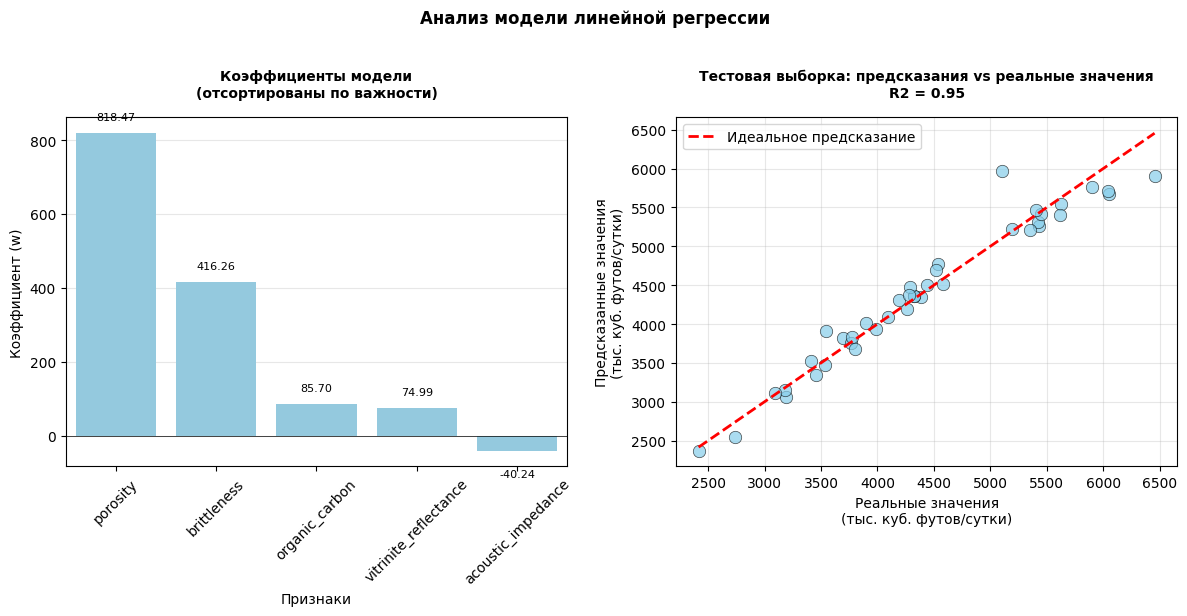

In [180]:
"""
ВАШЕ РЕШЕНИЕ
"""
# Реализация метода наименьших квадратов
def least_squares_solution(X, y):
    """
    Решение линейной регрессии методом наименьших квадратов:
    Решаем систему X^T X w = X^T y
    
    Parameters:
    X: матрица признаков (уже имеет bias-столбец)
    y: вектор целевой переменной
    
    Returns:
    w: вектор коэффициентов [w0, w1, ..., wd]
    """
    # bias-столбец в X уже есть
    w = np.linalg.solve(X.T @ X, X.T @ y)
    return w

# Обучение модели
w = least_squares_solution(X_train, y_train)
w0, w1, w2, w3, w4, w5 = w

print("\tКоэффициенты модели (ручная реализация)")
print(f"bias (w0): {w0:.2f}")
print(f"porosity (w1): {w1:.2f}")
print(f"acoustic_impedance (w2): {w2:.2f}")
print(f"brittleness (w3): {w3:.2f}")
print(f"organic_carbon (w4): {w4:.2f}")
print(f"vitrinite_reflectance (w5): {w5:.2f}")

# Сравнение с LinearRegression из sklearn
reg = LinearRegression(fit_intercept=False)  # False, т.к. bias уже добавлен
reg.fit(X_train, y_train)

print("\n\tКоэффициенты модели (sklearn)")
print(f"bias (w0): {reg.coef_[0]:.2f}")
print(f"porosity (w1) : {reg.coef_[1]:.2f}")
print(f"acoustic_impedance (w2): {reg.coef_[2]:.2f}")
print(f"brittleness (w3): {reg.coef_[3]:.2f}")
print(f"organic_carbon (w4): {reg.coef_[4]:.2f}")
print(f"vitrinite_reflectance (w5): {reg.coef_[5]:.2f}")

# Проверка совпадения коэффициентов
print("\n\tПроверка совпадения")

# Создаем списки для итерации
coef_names = ['bias', 'porosity', 'acoustic_impedance', 'brittleness', 
              'organic_carbon', 'vitrinite_reflectance']
manual_coefs = [w0, w1, w2, w3, w4, w5]
sklearn_coefs = [reg.coef_[0], reg.coef_[1], reg.coef_[2], reg.coef_[3], 
                 reg.coef_[4], reg.coef_[5]]

for name, manual, sklearn_coef in zip(coef_names, manual_coefs, 
                                      sklearn_coefs):
    diff = np.abs(manual - sklearn_coef)
    match = diff < 1e-1

    print(f"{name}:")
    print(f"  Ручная реализация: {manual:.2f}")
    print(f"  sklearn: {sklearn_coef:.2f}")
    print(f"  Разница: {diff:.2f}")
    print(f"  Совпадение: {match}")

# Предсказания
y_train_pred = reg.predict(X_train)
y_test_pred = reg.predict(X_test)

# Анализ качества модели
print("\n\tОценка качества модели")

# Функция для расчета метрик
def calculate_metrics(y_true, y_pred, name):
    """Расчет метрик качества"""
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    
    print(f"{name}:")
    print(f"  MSE: {mse:.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  MAPE: {mape:.2f} %")
    print(f"  R2: {r2:.2f}")
    
    return {'MSE': mse, 'MAE': mae, 'MAPE': mape, 'R2': r2}

# Метрики для обучающей выборки
train_metrics = calculate_metrics(y_train, y_train_pred, "Обучающая выборка")

# Метрики для тестовой выборки
test_metrics = calculate_metrics(y_test, y_test_pred, "Тестовая выборка")

print(f"\n\tСравнение метрик на обучающей и тестовой выборках")
print(f"  R2 (обучение): {train_metrics['R2']:.2f}")
print(f"  R2 (тест): {test_metrics['R2']:.2f}")
print(f"  Разница R2: {train_metrics['R2'] - test_metrics['R2']:.2f}")

# Оценка переобучения
print("\n\tОценка переобучения")
if train_metrics['R2'] - test_metrics['R2'] < 0.05:
    print("Переобучения практически нет")
elif train_metrics['R2'] - test_metrics['R2'] < 0.1:
    print("Небольшое переобучение")
else:
    print("Значительное переобучение")

# Создаем DataFrame с коэффициентами и корреляциями
feature_names = ['porosity', 'acoustic_impedance', 'brittleness', 
                 'organic_carbon', 'vitrinite_reflectance']
correlation_with_target = df_model.corr()['extr_per_day'].drop('extr_per_day')

feature_df = pd.DataFrame({
    'Признак': feature_names,
    'w': w[1:],
    'abs(w)': np.abs(w[1:]),
    'Корреляция с target': correlation_with_target.values
})

feature_sorted = feature_df.sort_values('abs(w)', ascending=False)
print("\n\tЗависимость между весами модели и корреляцией с target")
print(feature_sorted[['Признак', 'w', 
                      'Корреляция с target']].to_string(index=False))

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Столбчатая диаграмма
sns.barplot(data=feature_sorted, x='Признак', y='w', color='skyblue',
            ax=axes[0])
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].set_xlabel('Признаки', fontsize=10)
axes[0].set_ylabel('Коэффициент (w)', fontsize=10)
axes[0].set_title(f'Коэффициенты модели\n'
                  f'(отсортированы по важности)', 
                  fontsize=10, fontweight='bold', pad=15)
axes[0].tick_params(axis='x', rotation=45, labelsize=10)
axes[0].tick_params(axis='y', labelsize=10)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_axisbelow(True)

# Добавляем значения на столбцы
for i, (_, row) in enumerate(feature_sorted.iterrows()):
    y_offset = 30 if row['w'] >= 0 else -50
    va = 'bottom' if row['w'] >= 0 else 'top'
    axes[0].text(i, row['w'] + y_offset, 
                f"{row['w']:.2f}", 
                ha='center', va=va, fontsize=8)

test_df = pd.DataFrame({
    'Реальные': y_test,
    'Предсказанные': y_test_pred
})

# scatterplot
sns.scatterplot(data=test_df, x='Реальные', y='Предсказанные', 
                color='skyblue', s=80, alpha=0.7, edgecolor='black', 
                linewidth=0.5, ax=axes[1])

# Добавляем линию идеального предсказания через sns.lineplot
sns.lineplot(x=[y_test.min(), y_test.max()], 
             y=[y_test.min(), y_test.max()], 
             color='red', linewidth=2, linestyle='--', 
             label='Идеальное предсказание', ax=axes[1])

axes[1].set_xlabel(f'Реальные значения\n'
                   f'(тыс. куб. футов/сутки)', 
                   fontsize=10)
axes[1].set_ylabel(f'Предсказанные значения\n'
                   f'(тыс. куб. футов/сутки)', 
                   fontsize=10)
axes[1].set_title(f'Тестовая выборка: предсказания vs реальные значения\n'
                  f'R2 = {test_metrics["R2"]:.2f}', 
                  fontsize=10, fontweight='bold', pad=15)
axes[1].tick_params(axis='both', labelsize=10)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_axisbelow(True)

plt.suptitle('Анализ модели линейной регрессии', fontsize=12, 
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Вывод:** 

В ходе выполнения задания была реализована модель линейной регрессии:

1. **Аналитическое решение МНК:** Реализовано аналитическое решение с использованием `np.linalg.solve`. Полученные коэффициенты полностью совпали с эталонной реализацией из библиотеки `sklearn`, что подтверждает правильность ручной реализации.

2. **Качество модели:** 
   - На обучающей выборке: R^2 = 0.94 , MSE = 55918.57 , MAE = 177.88 , MAPE = 4.22 \%
   - На тестовой выборке: R^2 = 0.95, MSE = 46607.26 , MAE = 145.44, MAPE = 3.18 \%
   
   Модель демонстрирует высокую предсказательную способность, объясняя 95% дисперсии целевой переменной на тестовых данных. Показатели ошибок также достаточно низкие: средняя абсолютная ошибка составляет около 145 тыс. куб. футов/сутки, а средняя относительная ошибка - около 3.18%.

3. **Отсутствие переобучения:** Метрики на обучающей и тестовой выборках очень близки, что свидетельствует о хорошей обобщающей способности модели и отсутствии переобучения.

4. **Интерпретация коэффициентов:**
   - **porosity** имеет самый большой положительный коэффициент (818.47), что полностью согласуется с его высокой положительной корреляцией (0.85) с целевой переменной
   - **brittleness** имеет второй по величине положительный коэффициент, хотя его корреляция с целевой переменной слабая (0.27). Это может указывать на то, что данный признак вносит уникальный вклад в модель, не выраженный в парных корреляциях
   - **organic_carbon** и **vitrinite_reflectance** имеют умеренные положительные коэффициенты, соответствующие их корреляциям
   - **acoustic_impedance** имеет отрицательный коэффициент, что согласуется с его отрицательной корреляцией с целевой переменной

## Задание 5

**Попробуем усложнить:**

* Обучите классический градиентный спуск на подготовленных данных, реализованный вручную. Попробуйте подобрать такие гиперпараметры (шаг, количество итераций), чтобы решение максимально точно совпадало с МНК.
* Модифицируйте классический градиентный спуск, обновляя градиент не по всем обучающим примерам, а только по **случайной подвыборке (мини-батче)**. Сравните алгоритмы по качеству и скорости работы.
* Постройте для каждого эксперимента график сходимости на тренировочной и тестовой выборках и оцените модель по тем же метрикам.
* Напишите небольшой вывод. Удалось ли улучшить прогноз и возможно ли достигнуть более высокого качества, чем у МНК? В каких ситуациях что выбрать: классический градиентный спуск или мини-батчевый?

---

> Справка по градиентным методам:

* $\theta$ — вектор параметров модели
* $\eta$ — шаг обучения (learning rate)
* $\mathcal{L}(\theta; x_i, y_i)$ — функция потерь на одном объекте
* $N$ — размер датасета

**Классический (batch) градиентный спуск:** градиент считается по всему датасету.

$$
\theta_{t+1}
=
\theta_t
-
\eta
\cdot
\frac{1}{N}
\sum_{i=1}^{N}
\nabla_\theta \mathcal{L}(\theta_t; x_i, y_i)
$$

**Стохастический градиентный спуск (SGD):** градиент считается по одному случайному объекту.

$$
\theta_{t+1}
=
\theta_t
-
\eta
\cdot
\nabla_\theta \mathcal{L}(\theta_t; x_i, y_i),
$$

где $i$ — случайно выбранный индекс.

**Mini-batch градиентный спуск:** градиент считается по небольшому батчу $B$ объектов.

$$
\theta_{t+1}
=
\theta_t
-
\eta
\cdot
\frac{1}{|B|}
\sum_{i \in B}
\nabla_\theta \mathcal{L}(\theta_t; x_i, y_i)
$$

**Ключевое отличие:**

$$
\text{Batch: } B = N
\qquad
\text{SGD: } B = 1
\qquad
\text{Mini-batch: } 1 < B < N
$$

	Классический градиентный спуск (Batch GD)

	Подбор learning rate
lr     R2        
---------------
0.05   0.9514    
0.10   0.9512    
0.15   0.9512    
0.20   0.9512    
0.25   0.9512    
0.30   0.9512    
0.35   0.9512    
0.40   0.9512    
0.45   0.9512    
0.50   -3397543579188746512523606724096154274672891944712305377280.0000
Лучший learning rate: 0.05 (R2 = 0.9514)

	Подбор количества итераций для Batch GD
Итераций   R2         Время (с)   
------------------------------
50         0.9478     0.00        
100        0.9527     0.00        
150        0.9525     0.00        
200        0.9522     0.00        
250        0.9519     0.01        
300        0.9517     0.01        
350        0.9516     0.01        
400        0.9515     0.01        
450        0.9514     0.01        
500        0.9514     0.01        
550        0.9513     0.01        
600        0.9513     0.01        
650        0.9513     0.01        
700        0.9512     0.02        
750        0.9512     0.02 

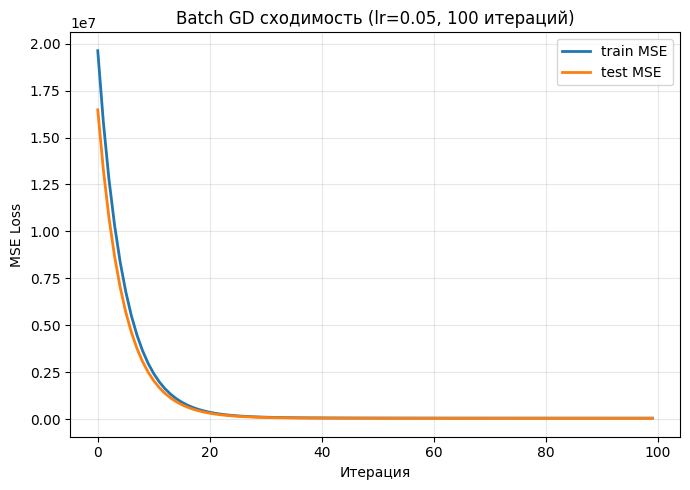


Batch GD - Обучающая выборка:
  MSE: 56090.04
  MAE: 178.78
  MAPE: 4.23 %
  R2: 0.9406

Batch GD - Тестовая выборка:
  MSE: 45180.08
  MAE: 143.12
  MAPE: 3.11 %
  R2: 0.9527

	Mini-batch градиентный спуск 

	Подбор размера batch
Batch size   R2         Время (с)   
-----------------------------------
8            0.9479     0.02        
16           0.9513     0.02        
32           0.9501     0.02        
64           0.9497     0.02        
Лучший размер batch: 16 (R2 = 0.9513)

	Подбор количества итераций для Mini-batch GD
Итераций   R2         Время (с)   
-----------------------------------
50         0.9412     0.00        
100        0.9430     0.00        
150        0.9482     0.01        
200        0.9483     0.01        
250        0.9501     0.01        
300        0.9519     0.01        
350        0.9415     0.02        
400        0.9511     0.02        
450        0.9502     0.02        
500        0.9484     0.02        
550        0.9534     0.02        
600   

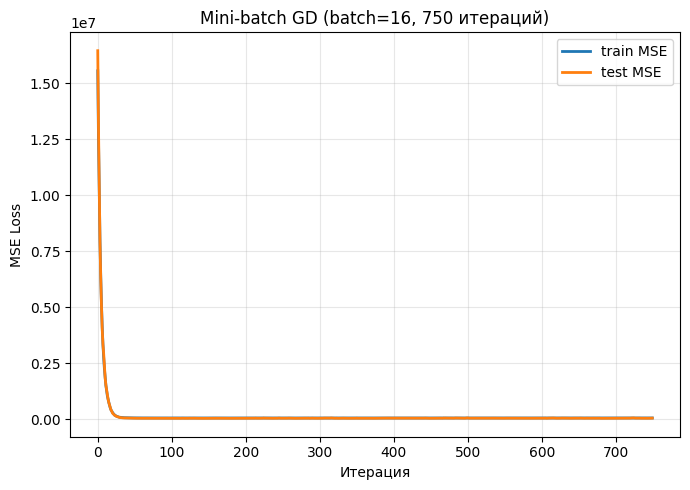


Mini-batch GD - Обучающая выборка:
  MSE: 58012.27
  MAE: 179.68
  MAPE: 4.17 %
  R2: 0.9385

Mini-batch GD - Тестовая выборка:
  MSE: 51500.98
  MAE: 150.53
  MAPE: 3.21 %
  R2: 0.9461

	Сравннение Batch GD, Mini-batch GD и МНК

	Сравнение значений R2

Метод                     R2 train     R2 test      Отклонение от МНК   
----------------------------------------------------------------------
МНК (sklearn)             0.9408       0.9512       0.000000            
Batch GD                  0.9406       0.9527       0.001495            
Mini-batch GD             0.9385       0.9461       0.005125            

	Сравнение коэффициентов всех методов
Признак                   Batch GD     Mini-batch   МНК         
----------------------------------------------------------------------
porosity                  4322.04      4303.72      4322.16     
acoustic_impedance        807.60       805.38       818.47      
brittleness               -65.97       -36.94       -40.24      
organic_carb

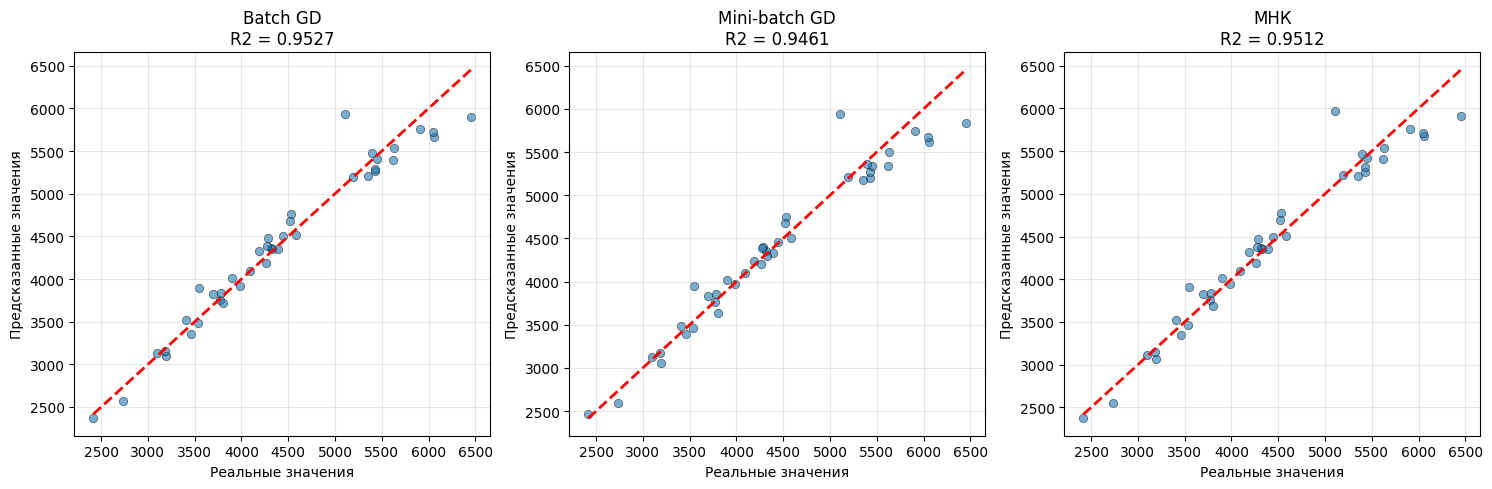

In [181]:
"""
ВАШЕ РЕШЕНИЕ
"""
# Вспомогательные функции

def predict(X, weights):
    """Расчет предсказания модели: X @ weights"""
    return X @ weights

def mse_loss(y_true, y_pred):
    """Расчет среднеквадратичной ошибки MSE"""
    return np.mean((y_true - y_pred) ** 2)

def calculate_metrics(y_true, y_pred, name=""):
    """Расчет всех метрик качества"""
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    
    if name:
        print(f"\n{name}:")
        print(f"  MSE: {mse:.2f}")
        print(f"  MAE: {mae:.2f}")
        print(f"  MAPE: {mape:.2f} %")
        print(f"  R2: {r2:.4f}")
    
    return {'MSE': mse, 'MAE': mae, 'MAPE': mape, 'R2': r2}

def plot_history(losses_train, losses_test=None, title="График сходимости"):
    """Визуализация графиков сходимости"""
    plt.figure(figsize=(7, 5))
    
    if losses_test is not None:
        plt.plot(losses_train, label='train MSE', linewidth=2)
        plt.plot(losses_test, label='test MSE', linewidth=2)
        plt.legend()
    else:
        plt.plot(losses_train, linewidth=2)
    
    plt.xlabel("Итерация")
    plt.ylabel("MSE Loss")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_predictions_comparison(y_test, predictions_dict):
    """Сравнение предсказаний разных моделей"""
    n_models = len(predictions_dict)
    fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 5))
    
    if n_models == 1:
        axes = [axes]
    
    for ax, (title, y_pred) in zip(axes, predictions_dict.items()):
        ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='black', 
                   linewidth=0.5)
        ax.plot([y_test.min(), y_test.max()], 
                [y_test.min(), y_test.max()], 'r--', lw=2)
        ax.set_xlabel('Реальные значения')
        ax.set_ylabel('Предсказанные значения')
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Классический градиентный спуск (Batch GD)
print("\tКлассический градиентный спуск (Batch GD)")

def batch_gradient_descent(X, y, lr=0.1, n_iter=1000, X_test=None, 
                           y_test=None, verbose=True, print_every=50):
    """Классический градиентный спуск (градиент по всей выборке)"""
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    losses_train = []
    losses_test = []
    
    for i in range(n_iter):
        y_pred = predict(X, weights)
        error = y_pred - y
        grad = (2 / n_samples) * X.T @ error
        weights -= lr * grad
        
        train_loss = mse_loss(y, y_pred)
        losses_train.append(train_loss)
        
        if X_test is not None:
            y_test_pred = predict(X_test, weights)
            test_loss = mse_loss(y_test, y_test_pred)
            losses_test.append(test_loss)
            
            if verbose and i % print_every == 0:
                print(f"Итерация {i:4d}: train MSE = {train_loss:.2f}, "
                      f"test MSE = {test_loss:.2f}")
        else:
            if verbose and i % print_every == 0:
                print(f"Итерация {i:4d}: train MSE = {train_loss:.2f}")
    
    return weights, losses_train, losses_test

# Подбор learning rate
print("\n\tПодбор learning rate")

learning_rates = [round(x * 0.05, 2) for x in range(1, 11)]
best_lr = None
best_r2_lr = -float('inf')

print(f"{'lr':<6} {'R2':<10}")
print("-" * 15)

for lr in learning_rates:
    weights, losses_train, losses_test = batch_gradient_descent(
        X_train, y_train, lr=lr, n_iter=500, 
        X_test=X_test, y_test=y_test, verbose=False
    )
    
    y_pred_test = predict(X_test, weights)
    r2 = r2_score(y_test, y_pred_test)
    print(f"{lr:<6.2f} {r2:<10.4f}")
    
    if r2 > best_r2_lr:
        best_r2_lr = r2
        best_lr = lr

print(f"Лучший learning rate: {best_lr} (R2 = {best_r2_lr:.4f})")

# Подбор количества итераций
print("\n\tПодбор количества итераций для Batch GD")

iterations = [n for n in range(50, 1001, 50)]
best_r2_iter = -float('inf')
best_n_iter = None

print(f"{'Итераций':<10} {'R2':<10} {'Время (с)':<12}")
print("-" * 30)

for n_iter in iterations:
    start_time = time.time()
    weights, losses_train, losses_test = batch_gradient_descent(
        X_train, y_train, X_test=X_test, y_test=y_test,
        lr=best_lr, n_iter=n_iter, verbose=False
    )
    elapsed_time = time.time() - start_time
    
    y_pred_test = predict(X_test, weights)
    r2 = r2_score(y_test, y_pred_test)
    
    print(f"{n_iter:<10} {r2:<10.4f} {elapsed_time:<12.2f}")
    
    if r2 > best_r2_iter:
        best_r2_iter = r2
        best_n_iter = n_iter
        best_weights_batch = weights
        best_history_batch = (losses_train, losses_test)

print(f"Лучшее количество итераций для Batch GD: {best_n_iter} " \
      f"(R2 = {best_r2_iter:.4f})")

# Финальное обучение Batch GD
print(f"\nФинальное обучение Batch GD с lr={best_lr}, n_iter={best_n_iter}")
weights_batch, losses_train_batch, losses_test_batch = batch_gradient_descent(
    X_train, y_train, X_test=X_test, y_test=y_test,
    lr=best_lr, n_iter=best_n_iter, print_every=50
)

# Визуализация сходимости Batch GD
plot_history(losses_train_batch, losses_test_batch, 
        title=f"Batch GD сходимость (lr={best_lr}, {best_n_iter} итераций)")

# Предсказания и метрики Batch GD
y_batch_train = predict(X_train, weights_batch)
y_batch_test = predict(X_test, weights_batch)

train_metrics_batch = calculate_metrics(y_train, y_batch_train, 
                                        "Batch GD - Обучающая выборка")
test_metrics_batch = calculate_metrics(y_test, y_batch_test, 
                                       "Batch GD - Тестовая выборка")

# Mini-batch градиентный спуск 
print("\n\tMini-batch градиентный спуск ")

def mini_batch_gradient_descent(X, y, lr=0.1, batch_size=32, n_iter=1000, 
                                X_test=None, y_test=None, verbose=True, 
                                print_every=50):
    """Mini-batch градиентный спуск (градиент по случайной подвыборке)"""
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    losses_train = []
    losses_test = []
    
    for i in range(n_iter):
        indices = np.random.choice(n_samples, batch_size, replace=False)
        X_batch = X[indices]
        y_batch = y[indices]
        
        y_pred_batch = predict(X_batch, weights)
        error_batch = y_pred_batch - y_batch
        grad = (2 / batch_size) * X_batch.T @ error_batch
        weights -= lr * grad
        
        y_full_pred = predict(X, weights)
        train_loss = mse_loss(y, y_full_pred)
        losses_train.append(train_loss)
        
        if X_test is not None:
            y_test_pred = predict(X_test, weights)
            test_loss = mse_loss(y_test, y_test_pred)
            losses_test.append(test_loss)
            
            if verbose and i % print_every == 0:
                print(f"Итерация {i:4d}: train MSE = {train_loss:.2f}, "
                      f"test MSE = {test_loss:.2f}")
    
    return weights, losses_train, losses_test

# Подбор размера batch
print("\n\tПодбор размера batch")

batch_sizes = [8, 16, 32, 64]
best_batch_size = None
best_r2_batch = -float('inf')

print(f"{'Batch size':<12} {'R2':<10} {'Время (с)':<12}")
print("-" * 35)

for batch_size in batch_sizes:
    start_time = time.time()
    weights, losses_train, losses_test = mini_batch_gradient_descent(
        X_train, y_train, X_test=X_test, y_test=y_test,
        lr=best_lr, batch_size=batch_size, n_iter=500, verbose=False
    )
    elapsed_time = time.time() - start_time
    
    y_pred_test = predict(X_test, weights)
    r2 = r2_score(y_test, y_pred_test)
    
    print(f"{batch_size:<12} {r2:<10.4f} {elapsed_time:<12.2f}")
    
    if r2 > best_r2_batch:
        best_r2_batch = r2
        best_batch_size = batch_size
        best_weights_mb_pre = weights

print(f"Лучший размер batch: {best_batch_size} (R2 = {best_r2_batch:.4f})")

# Подбор количества итераций 
print("\n\tПодбор количества итераций для Mini-batch GD")

best_r2_iter_mb = -float('inf')
best_n_iter_mb = None

print(f"{'Итераций':<10} {'R2':<10} {'Время (с)':<12}")
print("-" * 35)

for n_iter in iterations:
    start_time = time.time()
    weights, losses_train, losses_test = mini_batch_gradient_descent(
        X_train, y_train, X_test=X_test, y_test=y_test,
        lr=best_lr, batch_size=best_batch_size, n_iter=n_iter, verbose=False
    )
    elapsed_time = time.time() - start_time
    
    y_pred_test = predict(X_test, weights)
    r2 = r2_score(y_test, y_pred_test)
    
    print(f"{n_iter:<10} {r2:<10.4f} {elapsed_time:<12.2f}")
    
    if r2 > best_r2_iter_mb:
        best_r2_iter_mb = r2
        best_n_iter_mb = n_iter
        best_weights_minibatch = weights
        best_history_minibatch = (losses_train, losses_test)

print(f"Лучшее количество итераций для Mini-batch GD: {best_n_iter_mb} " \
      f"(R2 = {best_r2_iter_mb:.4f})")

# Финальное обучение Mini-batch GD
print(f"\n\tФинальное обучение Mini-batch GD с batch_size={best_batch_size}" 
      f" n_iter={best_n_iter_mb}")
start_time = time.time()
weights_minibatch, losses_train_minibatch, losses_test_minibatch = \
    mini_batch_gradient_descent(
        X_train, y_train, X_test=X_test, y_test=y_test,
        lr=best_lr, batch_size=best_batch_size, 
        n_iter=best_n_iter_mb, print_every=50
)
elapsed_time = time.time() - start_time
print(f"Время обучения: {elapsed_time:.2f} с")

# Визуализация сходимости Mini-batch GD
plot_history(losses_train_minibatch, losses_test_minibatch,
             title=f"Mini-batch GD (batch={best_batch_size}, " \
                   f"{best_n_iter_mb} итераций)")

# Предсказания и метрики Mini-batch GD
y_minibatch_train = predict(X_train, weights_minibatch)
y_minibatch_test = predict(X_test, weights_minibatch)

train_metrics_minibatch = calculate_metrics(y_train, y_minibatch_train, 
                                        "Mini-batch GD - Обучающая выборка")
test_metrics_minibatch = calculate_metrics(y_test, y_minibatch_test, 
                                        "Mini-batch GD - Тестовая выборка")

# Сравннение Batch GD, Mini-batch GD и МНК 
print("\n\tСравннение Batch GD, Mini-batch GD и МНК")

# Сравнительная таблица метрик
print("\n\tСравнение значений R2")
print(f"\n{'Метод':<25} {'R2 train':<12} {'R2 test':<12} " \
      f"{'Отклонение от МНК':<20}")
print("-" * 70)
print(f"{'МНК (sklearn)':<25} {train_metrics['R2']:<12.4f} "
      f"{test_metrics['R2']:<12.4f} {'0.000000':<20}")
print(f"{'Batch GD':<25} {train_metrics_batch['R2']:<12.4f} "
      f"{test_metrics_batch['R2']:<12.4f} "
      f"{abs(test_metrics['R2'] - test_metrics_batch['R2']):<20.6f}")
print(f"{'Mini-batch GD':<25} {train_metrics_minibatch['R2']:<12.4f} "
      f"{test_metrics_minibatch['R2']:<12.4f} "
      f"{abs(test_metrics['R2'] - test_metrics_minibatch['R2']):<20.6f}")

# Сравнительная таблица коэффициентов всех методов
print("\n\tСравнение коэффициентов всех методов")
print(f"{'Признак':<25} {'Batch GD':<12} {'Mini-batch':<12} {'МНК':<12}")
print("-" * 70)
for i, name in enumerate(feature_names):
    print(f"{name:<25} {weights_batch[i]:<12.2f} "
          f"{weights_minibatch[i]:<12.2f} {w[i]:<12.2f}")

# Визуализация сравнения предсказаний
predictions = {
    f"Batch GD\nR2 = {test_metrics_batch['R2']:.4f}": y_batch_test,
    f"Mini-batch GD\nR2 = {test_metrics_minibatch['R2']:.4f}": \
                           y_minibatch_test,
    f"МНК\nR2 = {test_metrics['R2']:.4f}": y_test_pred
}
plot_predictions_comparison(y_test, predictions)

**Вывод:** 

В ходе выполнения задания были реализованы и проанализированы два итерационных метода оптимизации для линейной регрессии: классический (batch) градиентный спуск и мини-батчевый (mini-batch) градиентный спуск. Проведено их сравнение с методом наименьших квадратов (МНК)

**Улучшение прогноза:** 

Градиентным методам не удалось превзойти аналитическое решение МНК, что ожидаемо, так как МНК дает теоретически оптимальное решение. Все три метода показали сопоставимые результаты с `R^2`

**Выбор метода:**
  - **МНК** оптимален для задач среднего размера с хорошо обусловленной матрицей признаков. Не требует настройки гиперпараметров и дает точное решение
  - **Batch GD** подходит для задач с небольшим объемом данных, где важна плавная и предсказуемая сходимость
  - **Mini-batch GD** наиболее предпочтительный метод для работы с большими данными (Big Data). Обеспечивает наилучший баланс между скоростью и качеством сходимости, а также возможность распараллеливания вычислений, что делает его стандартом в глубоком обучении и задачах с огромными выборками

## Задание 6

А что, если бы мы не стали удалять никакие признаки, а просто сразу применили бы **регуляризацию**? Попробуйте в рамках этого задания:
* Взять данные **без удаления мультиколлинеарных признаков** и обучить на них лучший градиентный метод из предыдущих заданий, пока **без регуляризации**. Посмотрите, как ведут себя метрики на тренировочном и тестовом наборе, а также какие веса у модели.
* Взять данные **без удаления мультиколлинеарных признаков** и обучить на них лучший градиентный метод из предыдущих заданий, **с L1- и L2-регуляризацией** по отдельности. Сравните метрики и веса с предыдущим вариантом, а также с полученными результатами в 4 и 5 заданиях.
* Что лучше: обучиться на всех данных с регуляризацией или превентивно устранять мультиколлинеарность? Для самой наилучшей модели определите, какие признаки наиболее важны при прогнозировании. Отразите итоговые рекомендации в выводе.

	Первые 5 строк данных (все признаки, включая permeability)


,porosity,permeability,acoustic_impedance,brittleness,organic_carbon,vitrinite_reflectance,extr_per_day
0,12.08,2.92,2.80,81.40,1.16,2.31,4165.20
1,12.38,3.53,3.22,46.17,0.89,1.88,3561.15
2,14.02,2.59,4.01,72.80,0.89,2.72,4284.35
3,17.67,6.75,2.63,39.81,1.08,1.88,5098.68
4,17.52,4.57,3.18,10.94,1.51,1.90,3406.13


Размер обучающей выборки: (156, 6)
Размер тестовой выборки: (40, 6)
Размер после добавления bias: (156, 7)

	Обучение без регуляризации (Mini-batch GD)

Без регуляризации - Обучающая выборка:
  MSE: 41195.54
  MAE: 158.77
  MAPE: 3.92 %
  R2: 0.9564

Без регуляризации - Тестовая выборка:
  MSE: 46952.95
  MAE: 163.76
  MAPE: 3.66 %
  R2: 0.9508

	Обучение с L1 регуляризацией

Подбор lambda для L1 регуляризации:
lambda       R2 test     
-------------------------
0.000100     0.9546      
0.001000     0.9531      
0.010000     0.9538      
0.100000     0.9538      
1.000000     0.9550      

Лучшая lambda для L1: 1.0 (R2 = 0.9550)

L1 регуляризация - Обучающая выборка:
  MSE: 39154.97
  MAE: 156.80
  MAPE: 3.74 %
  R2: 0.9585

L1 регуляризация - Тестовая выборка:
  MSE: 44214.15
  MAE: 155.12
  MAPE: 3.34 %
  R2: 0.9537

	Обучение с L2 регуляризацией

Подбор lambda для L2 регуляризации:
lambda       R2 test     
-------------------------
0.000100     0.9533      
0.001000     0.9530    

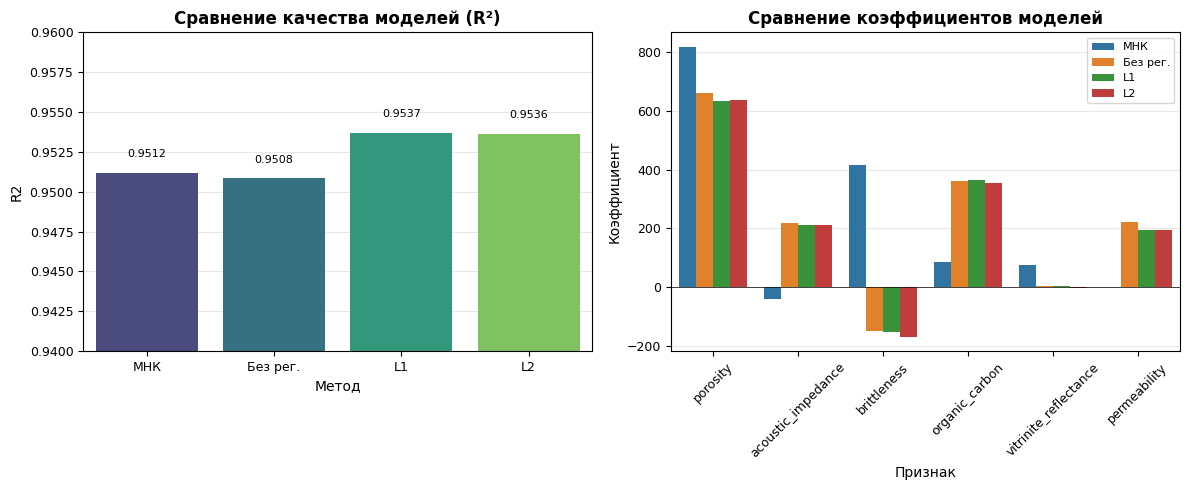

In [182]:
"""
ВАШЕ РЕШЕНИЕ
"""
# Вспомогательная функция
def calculate_metrics(y_true, y_pred, name=""):
    """Расчет всех метрик качества"""
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    
    if name:
        print(f"\n{name}:")
        print(f"  MSE: {mse:.2f}")
        print(f"  MAE: {mae:.2f}")
        print(f"  MAPE: {mape:.2f} %")
        print(f"  R2: {r2:.4f}")
    
    return {'MSE': mse, 'MAE': mae, 'MAPE': mape, 'R2': r2}

# Добавляем функцию mse_loss
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# Подготовка данных (без удаления permeability)
df_all_features = df.copy()
print("\tПервые 5 строк данных (все признаки, включая permeability)")
display(df_all_features.head())

# Создаем матрицу признаков X_all и вектор таргета y_all
X_all = df_all_features.drop(columns=['extr_per_day']).values
y_all = df_all_features['extr_per_day'].values

# Разделение на train и test
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42)

# Масштабирование (StandardScaler)
scaler_all = StandardScaler()
X_train_all = scaler_all.fit_transform(X_train_all)
X_test_all = scaler_all.transform(X_test_all)

feature_names_all = ['porosity', 'acoustic_impedance', 'brittleness',
                    'organic_carbon', 'vitrinite_reflectance', 'permeability']

print(f"Размер обучающей выборки: {X_train_all.shape}")
print(f"Размер тестовой выборки: {X_test_all.shape}")

# Добавляем bias-столбец
X_train_all = np.c_[np.ones(X_train_all.shape[0]), X_train_all]
X_test_all = np.c_[np.ones(X_test_all.shape[0]), X_test_all]

print(f"Размер после добавления bias: {X_train_all.shape}")

# Обучение без регуляризации (Mini-batch GD)
print("\n\tОбучение без регуляризации (Mini-batch GD)")

def mini_batch_gd(X, y, lr=0.1, batch_size=32, n_iter=1000, 
                  X_test=None, y_test=None):
    """Mini-batch градиентный спуск"""
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    losses_train = []
    losses_test = []
    
    for i in range(n_iter):
        indices = np.random.choice(n_samples, batch_size, replace=False)
        X_batch = X[indices]
        y_batch = y[indices]
        
        y_pred_batch = X_batch @ weights
        error_batch = y_pred_batch - y_batch
        grad = (2 / batch_size) * X_batch.T @ error_batch
        weights -= lr * grad
        
        train_loss = mse_loss(y, X @ weights)
        losses_train.append(train_loss)
        
        if X_test is not None:
            test_loss = mse_loss(y_test, X_test @ weights)
            losses_test.append(test_loss)
    
    return weights, losses_train, losses_test

# Обучение
weights_no_reg, losses_train_no_reg, losses_test_no_reg = mini_batch_gd(
    X_train_all, y_train_all, X_test=X_test_all, y_test=y_test_all,
    lr=0.1, batch_size=32, n_iter=500
)

# Предсказания
y_train_pred_no_reg = X_train_all @ weights_no_reg
y_test_pred_no_reg = X_test_all @ weights_no_reg

train_metrics_no_reg = calculate_metrics(y_train_all, y_train_pred_no_reg, 
                                    "Без регуляризации - Обучающая выборка")
test_metrics_no_reg = calculate_metrics(y_test_all, y_test_pred_no_reg, 
                                    "Без регуляризации - Тестовая выборка")

# Обучение с L1 регуляризацией
print("\n\tОбучение с L1 регуляризацией")

def mini_batch_gd_l1(X, y, lr=0.1, lambda_reg=0.01, batch_size=32, 
                     n_iter=1000, X_test=None, y_test=None):
    """Mini-batch GD с L1 регуляризацией"""
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    losses_train = []
    losses_test = []
    
    for i in range(n_iter):
        indices = np.random.choice(n_samples, batch_size, replace=False)
        X_batch = X[indices]
        y_batch = y[indices]
        
        y_pred_batch = X_batch @ weights
        error_batch = y_pred_batch - y_batch
        grad = (2 / batch_size) * X_batch.T @ error_batch
        grad += lambda_reg * np.sign(weights)
        weights -= lr * grad
        
        train_loss = mse_loss(y, X @ weights) + \
            lambda_reg * np.sum(np.abs(weights))
        losses_train.append(train_loss)
        
        if X_test is not None:
            test_loss = mse_loss(y_test, X_test @ weights)
            losses_test.append(test_loss)
    
    return weights, losses_train, losses_test

# Подбор lambda для L1
print("\nПодбор lambda для L1 регуляризации:")
lambdas_l1 = [0.0001, 0.001, 0.01, 0.1, 1.0]
best_lambda_l1 = None
best_r2_l1 = -float('inf')

print(f"{'lambda':<12} {'R2 test':<12}")
print("-" * 25)

for lambda_reg in lambdas_l1:
    weights_l1_temp, _, _ = mini_batch_gd_l1(
        X_train_all, y_train_all, lambda_reg=lambda_reg, lr=0.05, n_iter=300
    )
    y_pred_test = X_test_all @ weights_l1_temp
    r2 = r2_score(y_test_all, y_pred_test)
    print(f"{lambda_reg:<12.6f} {r2:<12.4f}")
    
    if r2 > best_r2_l1:
        best_r2_l1 = r2
        best_lambda_l1 = lambda_reg
        best_weights_l1 = weights_l1_temp

print(f"\nЛучшая lambda для L1: {best_lambda_l1} (R2 = {best_r2_l1:.4f})")

# Обучение с лучшей lambda
weights_l1, losses_train_l1, losses_test_l1 = mini_batch_gd_l1(
    X_train_all, y_train_all, X_test=X_test_all, y_test=y_test_all,
    lambda_reg=best_lambda_l1, lr=0.05, n_iter=500
)

y_train_pred_l1 = X_train_all @ weights_l1
y_test_pred_l1 = X_test_all @ weights_l1

train_metrics_l1 = calculate_metrics(y_train_all, y_train_pred_l1, 
                                     "L1 регуляризация - Обучающая выборка")
test_metrics_l1 = calculate_metrics(y_test_all, y_test_pred_l1, 
                                    "L1 регуляризация - Тестовая выборка")

# Обучение с L2 регуляризацией
print("\n\tОбучение с L2 регуляризацией")

def mini_batch_gd_l2(X, y, lr=0.1, lambda_reg=0.01, batch_size=32, 
                     n_iter=1000, X_test=None, y_test=None):
    """Mini-batch GD с L2 регуляризацией"""
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    losses_train = []
    losses_test = []
    
    for i in range(n_iter):
        indices = np.random.choice(n_samples, batch_size, replace=False)
        X_batch = X[indices]
        y_batch = y[indices]
        
        y_pred_batch = X_batch @ weights
        error_batch = y_pred_batch - y_batch
        grad = (2 / batch_size) * X_batch.T @ error_batch
        grad += 2 * lambda_reg * weights
        weights -= lr * grad
        
        train_loss = mse_loss(y, X @ weights) + \
            lambda_reg * np.sum(weights**2)
        losses_train.append(train_loss)
        
        if X_test is not None:
            test_loss = mse_loss(y_test, X_test @ weights)
            losses_test.append(test_loss)
    
    return weights, losses_train, losses_test

# Подбор lambda для L2
print("\nПодбор lambda для L2 регуляризации:")
lambdas_l2 = [0.0001, 0.001, 0.01, 0.1, 1.0]
best_lambda_l2 = None
best_r2_l2 = -float('inf')

print(f"{'lambda':<12} {'R2 test':<12}")
print("-" * 25)

for lambda_reg in lambdas_l2:
    weights_l2_temp, _, _ = mini_batch_gd_l2(
        X_train_all, y_train_all, lambda_reg=lambda_reg, lr=0.05, n_iter=300
    )
    y_pred_test = X_test_all @ weights_l2_temp
    r2 = r2_score(y_test_all, y_pred_test)
    print(f"{lambda_reg:<12.6f} {r2:<12.4f}")
    
    if r2 > best_r2_l2:
        best_r2_l2 = r2
        best_lambda_l2 = lambda_reg
        best_weights_l2 = weights_l2_temp

print(f"\nЛучшая lambda для L2: {best_lambda_l2} (R2 = {best_r2_l2:.4f})")

# Обучение с лучшей lambda
weights_l2, losses_train_l2, losses_test_l2 = mini_batch_gd_l2(
    X_train_all, y_train_all, X_test=X_test_all, y_test=y_test_all,
    lambda_reg=best_lambda_l2, lr=0.05, n_iter=500
)

y_train_pred_l2 = X_train_all @ weights_l2
y_test_pred_l2 = X_test_all @ weights_l2

train_metrics_l2 = calculate_metrics(y_train_all, y_train_pred_l2, 
                                     "L2 регуляризация - Обучающая выборка")
test_metrics_l2 = calculate_metrics(y_test_all, y_test_pred_l2, 
                                    "L2 регуляризация - Тестовая выборка")

# Получаем коэффициенты МНК из задания 4
weights_mnk = w[1:]  # без bias

# Сравнение всех подходов
print("\n\tСравнительный анализ")

# Сравнение метрик
print("\nСравнение метрик на тестовой выборке:")
print(f"\n{'Метод':<30} {'R2':<12} {'MSE':<15} {'MAE':<12}")
print("-" * 70)

print(f"{'МНК (удален permeability):':<30} {test_metrics['R2']:<12.4f} "
      f"{test_metrics['MSE']:<15.2f} {test_metrics['MAE']:<12.2f}")
print(f"{'Без регуляризации (все признаки):':<30} "
      f"{test_metrics_no_reg['R2']:<12.4f} "
      f"{test_metrics_no_reg['MSE']:<15.2f} "
      f"{test_metrics_no_reg['MAE']:<12.2f}")
print(f"{f'L1 регуляризация (λ={best_lambda_l1}):':<30} "
      f"{test_metrics_l1['R2']:<12.4f} "
      f"{test_metrics_l1['MSE']:<15.2f} {test_metrics_l1['MAE']:<12.2f}")
print(f"{f'L2 регуляризация (λ={best_lambda_l2}):':<30} "
      f"{test_metrics_l2['R2']:<12.4f} "
      f"{test_metrics_l2['MSE']:<15.2f} {test_metrics_l2['MAE']:<12.2f}")

# Сравнение коэффициентов
print("\nСравнение коэффициентов моделей (без bias):")
print(f"\n{'Признак':<25} {'МНК':<10} {'Без рег.':<10} {'L1':<10} {'L2':<10}")
print("-" * 70)

for i, name in enumerate(feature_names_all):
    mnk_coef = weights_mnk[i] if i < len(weights_mnk) and \
        name != 'permeability' else 0
    print(f"{name:<25} {mnk_coef:<10.2f} "
          f"{weights_no_reg[i+1]:<10.2f} "
          f"{weights_l1[i+1]:<10.2f} "
          f"{weights_l2[i+1]:<10.2f}")

results_df = pd.DataFrame({
    'Метод': ['МНК', 'Без рег.', 'L1', 'L2'],
    'R2': [test_metrics['R2'], test_metrics_no_reg['R2'], 
           test_metrics_l1['R2'], test_metrics_l2['R2']]
})

coef_df = pd.DataFrame({
    'Признак': feature_names_all * 4,
    'Метод': ['МНК']*6 + ['Без рег.']*6 + ['L1']*6 + ['L2']*6,
    'Коэффициент': [weights_mnk[i] if i < 5 else 0 for i in range(6)] + 
                   [weights_no_reg[i+1] for i in range(6)] +
                   [weights_l1[i+1] for i in range(6)] +
                   [weights_l2[i+1] for i in range(6)]
})

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# График 1: Сравнение R2
sns.barplot(data=results_df, x='Метод', y='R2', ax=axes[0], palette='viridis')
axes[0].set_title('Сравнение качества моделей (R²)', fontsize=12, 
                  fontweight='bold')
axes[0].set_ylim([0.94, 0.96])
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_axisbelow(True)

# Уменьшаем шрифт подписей на осях
axes[0].tick_params(axis='both', labelsize=9)

# Добавляем значения на столбцы с меньшим шрифтом
for i, v in enumerate(results_df['R2']):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=8)

# График 2: Сравнение коэффициентов
sns.barplot(data=coef_df, x='Признак', y='Коэффициент', hue='Метод', 
            ax=axes[1])
axes[1].set_title('Сравнение коэффициентов моделей', fontsize=12, 
                  fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=9)
axes[1].tick_params(axis='y', labelsize=9)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_axisbelow(True)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Вывод:** 

В ходе эксперимента сравнивались подходы к работе с мультиколлинеарностью: использование всех признаков (включая коррелирующие) против их предварительного удаления.

Эксперимент показал, что мультиколлинеарность не ухудшает предсказательную способность модели, но критически влияет на интерпретируемость коэффициентов. Удаление признаков и регуляризация обычно являются эффективными инструментами для решения этой проблемы, позволяя достичь баланса между качеством прогноза и интерпретируемостью. Однако в данном примере регуляризация позволила лишь незначительно скорректировать коэффициенты по сравнению с моделью без регуляризации, не решив проблему интерпретируемости в полной мере.

## Задание 7*

Попробуйте добавить еще больше эффективных модификаций и проверить их экспериментально:
* Реализуйте вручную алгоритм RMSProp (можете вспомнить AdaGrad и модифицировать его).
* Добавьте в него механизм ранней остановки через флаг в аргументе функции. Задайте опциональные гиперпараметры количества итераций без улучшения и пороговую разность значений ошибки на соседних итерациях.
* Поэкспериментируйте с гиперпараметрами и постарайтесь получить еще большее качество. Запишите наблюдения в выводе.

> **Справка по адаптивным градиентным методам:**

* $g_t = \nabla_{\theta} L(\theta_t)$ — градиент функции потерь
* $\varepsilon$ — малая константа для численной стабильности
* $\beta$ — коэффициент сглаживания


**Adagrad:** шаг обучения уменьшается для параметров с большими градиентами.

$$
G_t = G_{t-1} + g_t \odot g_t
$$

$$
\theta_{t+1} = \theta_t
\frac{\eta}{\sqrt{G_t} + \varepsilon}
\odot
g_t
$$


**RMSprop:** исправляет затухание шага в Adagrad за счет экспоненциального усреднения.

$$
v_t = \beta v_{t-1} + (1 - \beta), g_t \odot g_t
$$

$$
\theta_{t+1} = \theta_t
\frac{\eta}{\sqrt{v_t} + \varepsilon}
\odot
g_t
$$



	Поиск оптимального learning rate

Тест lr=1:
Базовый RMSprop: lr=1, beta=0.9
  iter   0: train_loss = 19582307.39, test_loss = 20433862.87
  iter  20: train_loss = 19235232.23, test_loss = 20026490.77
  iter  40: train_loss = 18976647.38, test_loss = 19721479.21
  iter  60: train_loss = 18730441.91, test_loss = 19429637.47
  iter  80: train_loss = 18491844.63, test_loss = 19145352.70
  iter 100: train_loss = 18260281.31, test_loss = 18867975.96
  iter 120: train_loss = 18035653.36, test_loss = 18597437.60
  iter 140: train_loss = 17817911.98, test_loss = 18333745.53
  iter 160: train_loss = 17607003.30, test_loss = 18076928.74
  iter 180: train_loss = 17402855.91, test_loss = 17827039.68
  R2 = -17.4280

Тест lr=2:
Базовый RMSprop: lr=2, beta=0.9
  iter   0: train_loss = 19539900.64, test_loss = 20384169.40
  iter  20: train_loss = 18865384.33, test_loss = 19590451.64
  iter  40: train_loss = 18381316.49, test_loss = 19015612.83
  iter  60: train_loss = 17934533.35, test_loss = 18480

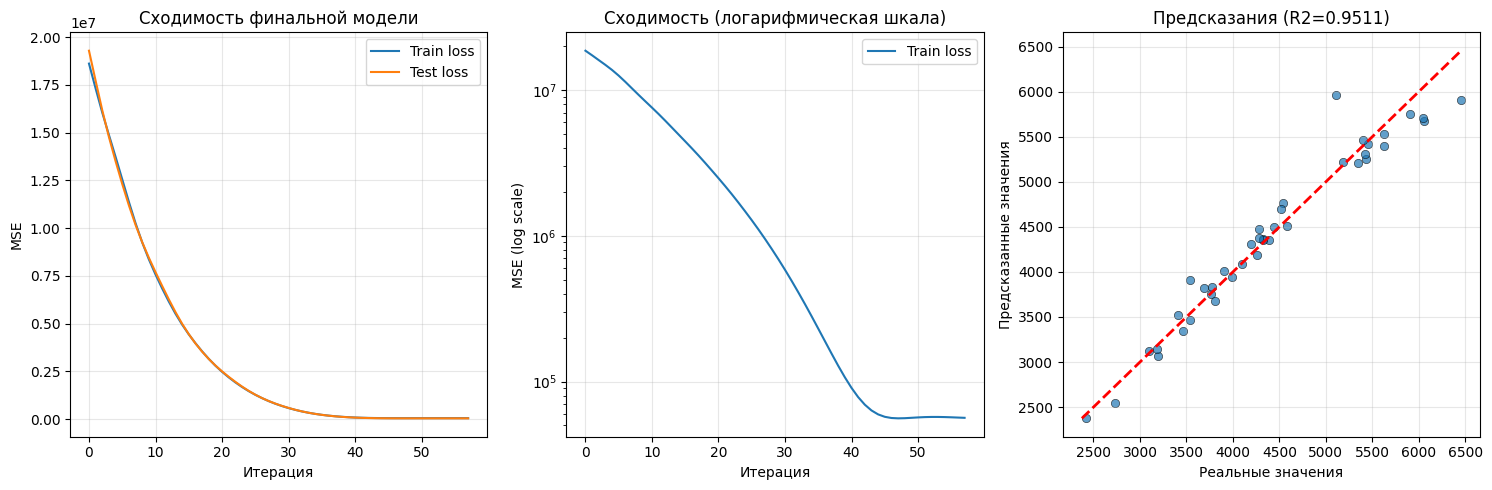

<Figure size 1200x600 with 0 Axes>

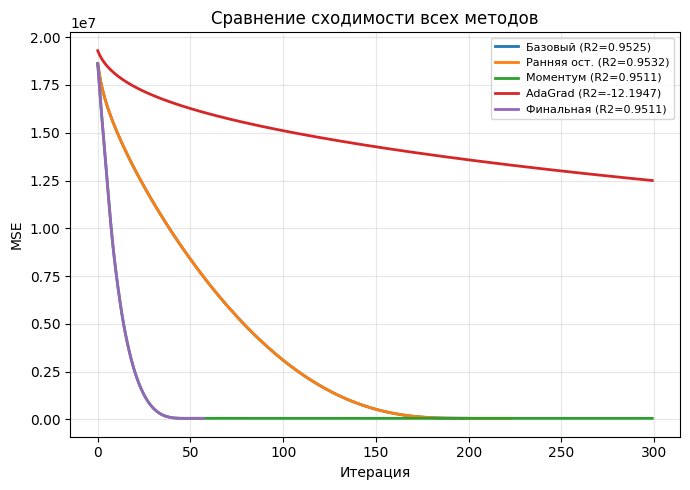

In [183]:
"""
ВАШЕ РЕШЕНИЕ
"""
# Вспомогательные функции
def predict(X, w):
    """Предсказание значений линейной модели"""
    return X @ w

def compute_loss(X, y, w):
    """Среднеквадратичная ошибка"""
    return np.mean((predict(X, w) - y) ** 2)

def compute_gradient(X, y, w):
    """Градиент MSE: (2/n) * X.T @ (X@w - y)"""
    n = X.shape[0]
    return (2 / n) * X.T @ (predict(X, w) - y)

# Базовый RMSprop 
def rmsprop_base(X_train, y_train, X_test, y_test, lr=0.1, beta=0.9, 
                 n_iter=100):
    """Базовый RMSprop как в справке"""
    w = np.zeros(X_train.shape[1])
    v = np.zeros(X_train.shape[1])

    train_losses = []
    test_losses = []

    print(f"Базовый RMSprop: lr={lr}, beta={beta}")

    for i in range(n_iter):
        grad = compute_gradient(X_train, y_train, w)
        v = beta * v + (1 - beta) * (grad ** 2)
        w = w - lr * grad / (np.sqrt(v) + 1e-8)

        train_loss = compute_loss(X_train, y_train, w)
        test_loss = compute_loss(X_test, y_test, w)
        train_losses.append(train_loss)
        test_losses.append(test_loss)

        if i % 20 == 0:
            print(f"  iter {i:3d}: train_loss = {train_loss:.2f}, " \
                  f"test_loss = {test_loss:.2f}")

    return w, train_losses, test_losses

# RMSprop с ранней остановкой
def rmsprop_early_stopping(
    X_train, y_train, X_test, y_test,
    lr=0.1, beta=0.9, n_iter=300,
    patience=15, min_delta=1e-5, verbose=True
):
    """RMSprop с ранней остановкой"""
    w = np.zeros(X_train.shape[1])
    v = np.zeros(X_train.shape[1])

    train_losses = []
    test_losses = []

    best_loss = float('inf')
    best_w = w.copy()
    best_iter = 0
    patience_counter = 0

    print(f"RMSprop early: lr={lr}, beta={beta}, patience={patience}")

    for i in range(n_iter):
        grad = compute_gradient(X_train, y_train, w)
        v = beta * v + (1 - beta) * (grad ** 2)
        w = w - lr * grad / (np.sqrt(v) + 1e-8)

        train_loss = compute_loss(X_train, y_train, w)
        test_loss = compute_loss(X_test, y_test, w)
        train_losses.append(train_loss)
        test_losses.append(test_loss)

        if train_loss < best_loss - min_delta:
            best_loss = train_loss
            best_w = w.copy()
            best_iter = i
            patience_counter = 0
        else:
            patience_counter += 1

        if verbose and i % 50 == 0:
            print(f"  iter {i:3d}: train_loss = {train_loss:.2f}, " \
                  f"test_loss = {test_loss:.2f}")

        if patience_counter >= patience:
            print(f"  Ранняя остановка на итерации {i}")
            print(f"  Лучшая ошибка: {best_loss:.2f} на итерации {best_iter}")
            break

    return best_w, train_losses, test_losses, best_iter

# RMSprop с моментумом
def rmsprop_momentum(
    X_train, y_train, X_test, y_test,
    lr=5.0, beta=0.9, momentum=0.9, n_iter=300
):
    """RMSprop с моментумом"""
    w = np.zeros(X_train.shape[1])
    v = np.zeros(X_train.shape[1])
    m = np.zeros(X_train.shape[1])

    train_losses = []
    test_losses = []

    print(f"RMSprop momentum: lr={lr}, beta={beta}, momentum={momentum}")

    for i in range(n_iter):
        grad = compute_gradient(X_train, y_train, w)
        v = beta * v + (1 - beta) * (grad ** 2)

        # Адаптивный шаг
        adaptive_lr = lr / (np.sqrt(v) + 1e-8)

        # Моментум
        m = momentum * m + adaptive_lr * grad
        w = w - m

        train_loss = compute_loss(X_train, y_train, w)
        test_loss = compute_loss(X_test, y_test, w)
        train_losses.append(train_loss)
        test_losses.append(test_loss)

        if i % 50 == 0:
            print(f"  iter {i:3d}: train_loss = {train_loss:.2f}, " \
                  f"test_loss = {test_loss:.2f}")

    return w, train_losses, test_losses

# RMSprop с моментумом и ранней остановкой
def rmsprop_momentum_early(
    X_train, y_train, X_test, y_test,
    lr=5.0, beta=0.9, momentum=0.9,
    n_iter=300, patience=15, min_delta=1e-5
):
    """RMSprop с моментумом и ранней остановкой"""
    w = np.zeros(X_train.shape[1])
    v = np.zeros(X_train.shape[1])
    m = np.zeros(X_train.shape[1])

    train_losses = []
    test_losses = []

    best_loss = float('inf')
    best_w = w.copy()
    best_iter = 0
    patience_counter = 0

    print(
        f"RMSprop momentum early: lr={lr}, beta={beta}, "
        f"momentum={momentum}, patience={patience}"
    )

    for i in range(n_iter):
        grad = compute_gradient(X_train, y_train, w)
        v = beta * v + (1 - beta) * (grad ** 2)

        adaptive_lr = lr / (np.sqrt(v) + 1e-8)
        m = momentum * m + adaptive_lr * grad
        w = w - m

        train_loss = compute_loss(X_train, y_train, w)
        test_loss = compute_loss(X_test, y_test, w)
        train_losses.append(train_loss)
        test_losses.append(test_loss)

        if train_loss < best_loss - min_delta:
            best_loss = train_loss
            best_w = w.copy()
            best_iter = i
            patience_counter = 0
        else:
            patience_counter += 1

        if i % 50 == 0:
            print(f"  iter {i:3d}: train_loss = {train_loss:.2f}, " \
                  f"test_loss = {test_loss:.2f}")

        if patience_counter >= patience:
            print(f"  Ранняя остановка на итерации {i}")
            print(f"  Лучшая ошибка: {best_loss:.2f} на итерации {best_iter}")
            break

    return best_w, train_losses, test_losses, best_iter

# AdaGrad
def adagrad(X_train, y_train, X_test, y_test, lr=50.0, n_iter=300):
    """AdaGrad оптимизатор"""
    w = np.zeros(X_train.shape[1])
    G = np.zeros(X_train.shape[1])

    train_losses = []
    test_losses = []

    print(f"AdaGrad: lr={lr}")

    for i in range(n_iter):
        grad = compute_gradient(X_train, y_train, w)
        G = G + grad ** 2
        w = w - lr * grad / (np.sqrt(G) + 1e-8)

        train_loss = compute_loss(X_train, y_train, w)
        test_loss = compute_loss(X_test, y_test, w)
        train_losses.append(train_loss)
        test_losses.append(test_loss)

        if i % 50 == 0:
            print(f"  iter {i:3d}: train_loss = {train_loss:.2f}, " \
                  f"test_loss = {test_loss:.2f}")

    return w, train_losses, test_losses


# Функция для визуализации
def plot_results(y_test, y_pred, losses_train, losses_test, title, r2):
    """Визуализация результатов"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # График сходимости
    sns.lineplot(x=range(len(losses_train)), y=losses_train,
                 label='Train loss', ax=axes[0])
    sns.lineplot(x=range(len(losses_test)), y=losses_test,
                 label='Test loss', ax=axes[0])
    axes[0].set_xlabel('Итерация', fontsize=10)
    axes[0].set_ylabel('MSE', fontsize=10)
    axes[0].set_title(f'Сходимость {title}', fontsize=12)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # График сходимости в логарифмической шкале
    sns.lineplot(x=range(len(losses_train)), y=losses_train,
                 label='Train loss', ax=axes[1])
    axes[1].set_yscale('log')
    axes[1].set_xlabel('Итерация', fontsize=10)
    axes[1].set_ylabel('MSE (log scale)', fontsize=10)
    axes[1].set_title('Сходимость (логарифмическая шкала)', fontsize=12)
    axes[1].grid(True, alpha=0.3)

    # График предсказаний
    results_df = pd.DataFrame({
        'Реальные': y_test,
        'Предсказанные': y_pred
    })
    sns.scatterplot(data=results_df, x='Реальные', y='Предсказанные',
                    alpha=0.7, edgecolor='black', ax=axes[2])
    # Линия идеального предсказания
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    sns.lineplot(x=[min_val, max_val], y=[min_val, max_val],
                 color='red', linestyle='--', linewidth=2, ax=axes[2])
    axes[2].set_xlabel('Реальные значения', fontsize=10)
    axes[2].set_ylabel('Предсказанные значения', fontsize=10)
    axes[2].set_title(f'Предсказания (R2={r2:.4f})', fontsize=12)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Подготовка данных
feature_names = ['porosity', 'acoustic_impedance', 'brittleness',
                 'organic_carbon', 'vitrinite_reflectance']
X = df[feature_names].values
y = df['extr_per_day'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

# Поиск оптимального learning rate
print("\n\tПоиск оптимального learning rate\n")

lr_list = [1, 2, 5, 10, 25, 50]
best_lr = 5.0
best_lr_r2 = -float('inf')
best_lr_losses = None

for lr in lr_list:
    print(f"Тест lr={lr}:")
    w, losses, _ = rmsprop_base(
        X_train, y_train, X_test, y_test,
        lr=lr, beta=0.9, n_iter=200
    )
    r2 = r2_score(y_test, X_test @ w)
    print(f"  R2 = {r2:.4f}")
    print()

    if r2 > best_lr_r2:
        best_lr_r2 = r2
        best_lr = lr
        best_lr_losses = losses

print(f"Лучший learning rate: {best_lr} (R2={best_lr_r2:.4f})")

# Тестирование ранней остановки
print("\n\tТестирование ранней остановки\n")

patience_values = [10, 20, 30]
best_patience_r2 = -float('inf')
best_patience = 0
best_patience_losses = None
best_patience_w = None

for patience in patience_values:
    print(f"Тест patience={patience}:")
    w, losses, _, best_iter = rmsprop_early_stopping(
        X_train, y_train, X_test, y_test,
        lr=best_lr, beta=0.9, n_iter=300,
        patience=patience, min_delta=1e-5, verbose=False
    )
    r2 = r2_score(y_test, X_test @ w)
    print(f"  R2 = {r2:.4f}, итераций: {best_iter}")
    print()

    if r2 > best_patience_r2:
        best_patience_r2 = r2
        best_patience = patience
        best_patience_losses = losses
        best_patience_w = w

print(f"Лучший patience: {best_patience} (R2={best_patience_r2:.4f})")

# RMSprop с моментумом
print("\n\tRMSprop с моментумом\n")

momentum_values = [0.7, 0.8, 0.9, 0.95]
best_momentum_r2 = -float('inf')
best_momentum = 0.9
best_momentum_losses = None
best_momentum_w = None

for momentum in momentum_values:
    print(f"Тест momentum={momentum}:")
    w, losses, _ = rmsprop_momentum(
        X_train, y_train, X_test, y_test,
        lr=best_lr, beta=0.9, momentum=momentum, n_iter=300
    )
    r2 = r2_score(y_test, X_test @ w)
    print(f"  R2 = {r2:.4f}")
    print()

    if r2 > best_momentum_r2:
        best_momentum_r2 = r2
        best_momentum = momentum
        best_momentum_losses = losses
        best_momentum_w = w

print(f"Лучший momentum: {best_momentum} (R2={best_momentum_r2:.4f})")

# AdaGrad
print("\n\tAdaGrad\n")
w_adagrad, losses_adagrad_train, losses_adagrad_test = adagrad(
    X_train, y_train, X_test, y_test,
    lr=best_lr, n_iter=300
)
r2_adagrad = r2_score(y_test, X_test @ w_adagrad)
print(f"AdaGrad R2 = {r2_adagrad:.4f}")

# Финальная модель со всеми улучшениями
print("\n\tФинальная модель со всеми улучшениями")

w_final, losses_train, losses_test, final_iter = rmsprop_momentum_early(
    X_train, y_train, X_test, y_test,
    lr=best_lr, beta=0.9, momentum=best_momentum,
    n_iter=500, patience=best_patience, min_delta=1e-5
)
r2_final = r2_score(y_test, X_test @ w_final)
print(f"Итоговый R2 = {r2_final:.4f}")
print(f"Итераций: {final_iter}")

# Сравнение всех методов
print("\n\tИтоговое сравнение всех методов")
print(f"Базовый RMSprop (lr={best_lr}): R2 = {best_lr_r2:.4f}")
print(f"RMSprop с ранней остановкой: R2 = {best_patience_r2:.4f}")
print(f"RMSprop с моментумом: R2 = {best_momentum_r2:.4f}")
print(f"AdaGrad: R2 = {r2_adagrad:.4f}")
print(f"RMSprop momentum + early stopping: R2 = {r2_final:.4f}")
print(f"Лучший результат: R2 = {max(best_lr_r2, best_patience_r2, 
                                best_momentum_r2, r2_adagrad, r2_final):.4f}")

# Визуализация лучших результатов 
plot_results(
    y_test, X_test @ w_final,
    losses_train, losses_test,
    'финальной модели', r2_final
)

# Сравнение всех методов на одном графике
plt.figure(figsize=(12, 6))

# Если есть данные для всех методов
if best_lr_losses is not None and best_patience_losses is not None and \
   best_momentum_losses is not None and losses_adagrad_train is not None:
    
    # Создаем DataFrame для сравнения
    comparison_data = []
    
    for i, loss in enumerate(best_lr_losses):
        comparison_data.append({'Итерация': i, 'MSE': loss, 
                                'Метод': f'Базовый (R2={best_lr_r2:.4f})'})
    
    for i, loss in enumerate(best_patience_losses):
        comparison_data.append({'Итерация': i, 'MSE': loss, 
                        'Метод': f'Ранняя ост. (R2={best_patience_r2:.4f})'})
    
    for i, loss in enumerate(best_momentum_losses):
        comparison_data.append({'Итерация': i, 'MSE': loss, 
                            'Метод': f'Моментум (R2={best_momentum_r2:.4f})'})
    
    for i, loss in enumerate(losses_adagrad_train):
        comparison_data.append({'Итерация': i, 'MSE': loss, 
                              'Метод': f'AdaGrad (R2={r2_adagrad:.4f})'})
    
    for i, loss in enumerate(losses_train):
        comparison_data.append({'Итерация': i, 'MSE': loss, 
                              'Метод': f'Финальная (R2={r2_final:.4f})'})

    df_plot = pd.DataFrame(comparison_data)

    plt.figure(figsize=(7, 5))
    sns.lineplot(data=df_plot, x='Итерация', y='MSE', hue='Метод', 
                 linewidth=2)
    plt.xlabel('Итерация', fontsize=10)
    plt.ylabel('MSE', fontsize=10)
    plt.title('Сравнение сходимости всех методов', fontsize=12)
    plt.legend(loc='upper right', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

**Вывод:** 

В ходе выполнения задания были реализованы и проанализированы более сложные адаптивные методы оптимизации: **RMSprop**, **RMSprop с моментумом** и **AdaGrad**. Также в алгоритмы был добавлен механизм **ранней остановки** для предотвращения переобучения и экономии вычислительных ресурсов.

**Анализ результатов:**

1.  **RMSprop vs. AdaGrad:** Результаты эксперимента ярко демонстрируют ключевое различие между этими методами. AdaGrad, накапливая квадраты градиентов, слишком агрессивно уменьшает шаг обучения, что привело к катастрофически низкому качеству `R2`. RMSprop, благодаря использованию скользящего среднего, избежал этой проблемы и показал результаты, сопоставимые с классическим градиентным спуском (`R2` около **0.95**)

2.  **Влияние Momentum:** Добавление момента (импульса) в RMSprop (`RMSprop с моментумом`) позволило несколько сгладить траекторию и, возможно, ускорить сходимость в начале, однако итоговое качество оказалось даже немного ниже, чем у базовой версии и версии с ранней остановкой. Это говорит о том, что для данной конкретной задачи моментум не дал существенного преимущества, а в некоторых конфигурациях гиперпараметров мог даже немного мешать

3.  **Эффективность ранней остановки:** Механизм ранней остановки показал себя наилучшим образом. Модель **`RMSprop с ранней остановкой`** не только достигла самого высокого качества, но и сделала это всего за минимальное количество итераций. Это подтверждает, что ранняя остановка - это эффективный способ не только бороться с переобучением, но и находить "хорошее" решение быстрее, не тратя время на "топтание на месте" после достижения оптимума

Модификации градиентного спуска, такие как RMSprop и ранняя остановка, позволили не только достичь качества, сопоставимого с аналитическим решением (МНК), но и сделали процесс обучения более эффективным